<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/comparesimulations2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Benchmarking and optimizing an offshore oil-and-gas process with NeqSim

This notebook rebuilds the published Andreasen separation and compression case as a reusable
NeqSim process, compares the base-case responses with the published Aspen HYSYS values, and then
demonstrates deterministic sampling, direct optimization, surrogate modeling, and parallel
execution. The published values are a comparison target, not an exact regression oracle, because
liquid-density models and some equipment details differ.

In [1]:
# Pin the diagram runtime to the exact accepted NeqSim implementation.
# A supplied local JAR makes CI/developer validation fast. Colab builds the same public commit.
import hashlib
import os
import subprocess
from pathlib import Path

NEQSIM_DIAGRAM_COMMIT = "653db71353dc3a5a0fad92b945978fd0bd94e74a"
supplied_jar = os.environ.get("NEQSIM_EXACT_JAR", "").strip()

if supplied_jar:
    diagram_runtime_jar = Path(supplied_jar).expanduser().resolve()
    if not diagram_runtime_jar.is_file():
        raise FileNotFoundError(f"NEQSIM_EXACT_JAR does not exist: {diagram_runtime_jar}")
    diagram_runtime_source = "supplied exact-commit validation artifact"
else:
    source_dir = Path("neqsim-diagram-runtime")
    if not source_dir.exists():
        subprocess.check_call(["git", "init", str(source_dir)])
        subprocess.check_call(
            [
                "git",
                "-C",
                str(source_dir),
                "remote",
                "add",
                "origin",
                "https://github.com/equinor/neqsim.git",
            ]
        )
        subprocess.check_call(
            ["git", "-C", str(source_dir), "fetch", "--depth", "1", "origin", NEQSIM_DIAGRAM_COMMIT]
        )
        subprocess.check_call(["git", "-C", str(source_dir), "checkout", "--detach", "FETCH_HEAD"])
    checked_out = subprocess.check_output(
        ["git", "-C", str(source_dir), "rev-parse", "HEAD"], text=True
    ).strip()
    if checked_out != NEQSIM_DIAGRAM_COMMIT:
        raise RuntimeError(f"Expected {NEQSIM_DIAGRAM_COMMIT}, found {checked_out}")
    subprocess.check_call(
        ["./mvnw", "-q", "-DskipTests", "-Dmaven.javadoc.skip=true", "package"], cwd=source_dir
    )
    jars = sorted((source_dir / "target").glob("neqsim-*.jar"))
    jars = [path for path in jars if not path.name.endswith(("-sources.jar", "-javadoc.jar"))]
    if len(jars) != 1:
        raise RuntimeError(
            f"Expected one executable NeqSim JAR, found {[str(path) for path in jars]}"
        )
    diagram_runtime_jar = jars[0].resolve()
    diagram_runtime_source = f"source build of {NEQSIM_DIAGRAM_COMMIT}"

diagram_runtime_sha256 = hashlib.sha256(diagram_runtime_jar.read_bytes()).hexdigest()
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
print(f"Diagram runtime: {diagram_runtime_source}")
print(f"Java commit: {NEQSIM_DIAGRAM_COMMIT}")
print(f"JAR SHA-256: {diagram_runtime_sha256}")

Diagram runtime: supplied exact-commit validation artifact
Java commit: 653db71353dc3a5a0fad92b945978fd0bd94e74a
JAR SHA-256: 8b2eeb94e972e0c30467ad9c4f99f299b5fe9eec57b55f0e4ff4dd5896ec6704


In [2]:
import hashlib
import importlib.metadata
import importlib.util
import os
import platform
import subprocess
import sys
from pathlib import Path

REQUIRED_DISTRIBUTIONS = {
    "neqsim": "neqsim",
    "pydantic": "pydantic",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
    "graphviz": "graphviz",
}

missing_distributions = [
    distribution
    for module, distribution in REQUIRED_DISTRIBUTIONS.items()
    if importlib.util.find_spec(module) is None
]

if missing_distributions:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            *missing_distributions,
        ]
    )

import jpype

jpype.addClassPath(str(diagram_runtime_jar))
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import neqsim as neqsim_package
from neqsim import jneqsim as neqsim
from neqsim.neqsimpython import init_jvm

init_jvm()

neqsim_version = importlib.metadata.version("neqsim")
neqsim_directory = Path(neqsim_package.__file__).resolve().parent
neqsim_jars = sorted((neqsim_directory / "lib").glob("neqsim-*.jar"))

if len(neqsim_jars) != 1:
    raise RuntimeError(f"Expected one packaged NeqSim JAR, found {len(neqsim_jars)}")

packaged_neqsim_jar = neqsim_jars[0]
neqsim_jar = diagram_runtime_jar
neqsim_jar_sha256 = diagram_runtime_sha256
java_version = str(jpype.java.lang.System.getProperty("java.version"))

runtime_provenance = pd.DataFrame(
    {
        "Item": [
            "NeqSim Python package",
            "Python",
            "Java",
            "Runtime JAR",
            "JAR SHA-256",
            "Java commit",
        ],
        "Value": [
            neqsim_version,
            platform.python_version(),
            java_version,
            neqsim_jar.name,
            neqsim_jar_sha256,
            NEQSIM_DIAGRAM_COMMIT,
        ],
    }
)
runtime_provenance


,Item,Value
0,NeqSim Python package,3.20.0
1,Python,3.12.14
2,Java,17.0.20
3,Runtime JAR,neqsim-3.20.0.jar
4,JAR SHA-256,8b2eeb94e972e0c30467ad9c4f99f299b5fe9eec57b55f...
5,Java commit,653db71353dc3a5a0fad92b945978fd0bd94e74a


## Scope, learning objectives, and engineering boundary

After completing the notebook you should be able to:

- characterize a 17-component petroleum fluid with a Peng-Robinson equation of state;
- assemble separators, mixers, coolers, compressors, pumps, recycles, and export streams into a
  connected NeqSim `ProcessSystem`;
- retrieve compact engineering results and verify mass closure, pressure hierarchy, finite duties,
  and product-quality indicators;
- compare the NeqSim base case with the published HYSYS benchmark;
- generate a deterministic 100-case Latin-hypercube design, train and validate a surrogate, and
  check the proposed optimum with the rigorous NeqSim model;
- use both `runAsThread()` and the managed `NeqSimThreadPool` for independent process cases.

The paper used HYSYS 10, Peng-Robinson thermodynamics, COSTALD liquid density, and a detailed
utility/profit model. This teaching implementation uses current public NeqSim APIs and focuses on
process thermodynamics, equipment loads, product flows, and reproducible optimization mechanics.
It is not a design certification or a substitute for model reconciliation against plant data.

## Reference case

The process topology and operating basis follow Andreasen, *Applied Process Simulation-Driven Oil
and Gas Separation Plant Optimization Using Surrogate Modeling and Evolutionary Algorithms*,
ChemEngineering 4 (2020) 11, https://doi.org/10.3390/chemengineering4010011.

A related fluid-characterization source is https://doi.org/10.1002/apj.159. The workflow keeps the
published HYSYS result separate from the current NeqSim result so that model-form differences are
visible rather than tuned away.

## 1. Create the petroleum fluid

The original 17-component assay is preserved. Nine named light components are followed by eight
characterized C7+ pseudo-components. Amounts are normalized internally before the process model
receives the composition. Pressure is absolute unless explicitly labelled `barg`; temperature is
in degrees Celsius at the Python interface.

In [3]:
wellfluid = neqsim.thermo.system.SystemPrEos()
wellfluid.getCharacterization().setTBPModel("Two")
wellfluid.addComponent("CO2", 1.5870)
wellfluid.addComponent("methane", 52.51)
wellfluid.addComponent("ethane", 6.24)
wellfluid.addComponent("propane", 4.23)
wellfluid.addComponent("i-butane", 0.855)
wellfluid.addComponent("n-butane", 2.213)
wellfluid.addComponent("i-pentane", 1.124)
wellfluid.addComponent("n-pentane", 1.271)
wellfluid.addComponent("n-hexane", 2.289)
wellfluid.addTBPfraction("C7+_cut1", 0.8501, 108.47 / 1000.0, 0.7411)
wellfluid.addTBPfraction("C7+_cut2", 1.2802, 120.4 / 1000.0, 0.755)
wellfluid.addTBPfraction("C7+_cut3", 1.6603, 133.64 / 1000.0, 0.7695)
wellfluid.addTBPfraction("C7+_cut4", 6.5311, 164.70 / 1000.0, 0.799)
wellfluid.addTBPfraction("C7+_cut5", 6.3311, 215.94 / 1000.0, 0.8387)
wellfluid.addTBPfraction("C7+_cut6", 4.9618, 273.34 / 1000.0, 0.8754)
wellfluid.addTBPfraction("C7+_cut7", 2.9105, 334.92 / 1000.0, 0.90731)
wellfluid.addTBPfraction("C7+_cut8", 3.0505, 412.79 / 1000.0, 0.94575)
wellfluid.setMixingRule("classic")
# A two-phase flash is sufficient for this published benchmark composition.
# The volume-translation setting remains at the NeqSim default used for the comparison.


### Alternative Eclipse-format fluid import

The original alternative import remains operational, but the small public example is embedded so
that execution does not depend on a mutable URL or current working directory. This seven-lump SRK
fluid is an API demonstration and is not substituted for the 17-component benchmark fluid.

In [4]:
from pathlib import Path

from neqsim.thermo.thermoTools import TPflash, readEclipseFluid

ECLIPSE_FLUID_LINES = [
    "-- Generated with ...\n",
    "-- Fluid: TEST       \n",
    "-- Database: test\n",
    "-- Units\n",
    "METRIC\n",
    "-- Number of components:\n",
    "NCOMPS\n",
    " 7 /\n",
    "-- Equation of state\n",
    "EOS\n",
    "SRK /\n",
    "-- Reservoir temperature (C)\n",
    "RTEMP\n",
    "     30.00 /\n",
    "-- Standard Conditions (C and bara)\n",
    "STCOND\n",
    "   15.00000    1.01325  /\n",
    "-- Component names\n",
    "CNAMES\n",
    "N2+C1\n",
    "CO2+C2+C\n",
    "iC4-C6\n",
    "C7-C10\n",
    "C11-C20\n",
    "C21-C35\n",
    "C36-C80 /\n",
    "-- Tc (K)\n",
    "TCRIT\n",
    "   190.491\n",
    "   326.113\n",
    "   456.737\n",
    "   536.885\n",
    "   638.575\n",
    "   780.675\n",
    "   933.953 /\n",
    "-- Pc (Bar)\n",
    "PCRIT\n",
    "   45.9811\n",
    "   52.4076\n",
    "   34.3310\n",
    "   26.6653\n",
    "   24.3755\n",
    "   21.3919\n",
    "   22.1465 /\n",
    "-- Omega\n",
    "ACF\n",
    "   0.00805\n",
    "   0.14438\n",
    "   0.23198\n",
    "   0.51020\n",
    "   0.70682\n",
    "   1.03701\n",
    "   1.32441 /\n",
    "-- OmegaA\n",
    "OMEGAA\n",
    "     0.42748\n",
    "     0.42748\n",
    "     0.42748\n",
    "     0.42748\n",
    "     0.42748\n",
    "     0.42748\n",
    "     0.42748 /\n",
    "-- OmegaB\n",
    "OMEGAB\n",
    "     0.08664\n",
    "     0.08664\n",
    "     0.08664\n",
    "     0.08664\n",
    "     0.08664\n",
    "     0.08664\n",
    "     0.08664 /\n",
    "-- Molecular weights\n",
    "MW\n",
    "   16.0545\n",
    "   36.4677\n",
    "   68.0160\n",
    "  109.1187\n",
    "  177.1353\n",
    "  322.5892\n",
    "  527.7741 /\n",
    "-- Boiling points (K)\n",
    "TBOIL\n",
    "   111.542\n",
    "   202.030\n",
    "   299.301\n",
    "   395.126\n",
    "   507.605\n",
    "   653.271\n",
    "   780.883 /\n",
    "-- Critical volumes (m3/kg-mole)\n",
    "VCRIT\n",
    "   0.09898\n",
    "   0.15368\n",
    "   0.30130\n",
    "   0.54085\n",
    "   0.74300\n",
    "   1.37772\n",
    "   2.51445 /\n",
    "-- Critical Z-factors\n",
    "ZCRIT\n",
    "   0.28736\n",
    "   0.29703\n",
    "   0.27237\n",
    "   0.32307\n",
    "   0.34110\n",
    "   0.45404\n",
    "   0.71709 /\n",
    "-- Volume translation/co-volume\n",
    "SSHIFT\n",
    "  0.021119\n",
    "  0.074945\n",
    "  0.114077\n",
    "  0.129432\n",
    " -0.010859\n",
    " -0.195030\n",
    " -0.550531 /\n",
    "-- Parachors (dyn/cm)\n",
    "PARACHOR\n",
    "    77.238\n",
    "   115.909\n",
    "   222.744\n",
    "   318.521\n",
    "   487.782\n",
    "   823.698\n",
    "  1298.022 /\n",
    "-- Overall composition\n",
    "ZI\n",
    "  0.824420\n",
    "  0.106839\n",
    "  0.036416\n",
    "  0.024350\n",
    "  0.007734\n",
    "  0.000240\n",
    "  0.000001 /\n",
    "-- Binary interaction coefficients for SRK\n",
    "BIC\n",
    "  0.0225\n",
    "  0.0001  0.0225\n",
    "  0.0001  0.0188  0.0000\n",
    "  0.0001  0.0188  0.0000  0.0000\n",
    "  0.0001  0.0188  0.0000  0.0000  0.0000\n",
    "  0.0001  0.0188  0.0000  0.0000  0.0000  0.0000\n",
    "/\n",
    "BICS\n",
    "  0.0225\n",
    "  0.0001  0.0225\n",
    "  0.0001  0.0188  0.0000\n",
    "  0.0001  0.0188  0.0000  0.0000\n",
    "  0.0001  0.0188  0.0000  0.0000  0.0000\n",
    "  0.0001  0.0188  0.0000  0.0000  0.0000  0.0000\n",
    "/\n",
    "-- LBC coefficients\n",
    "LBCCOEF\n",
    "   0.1023000    0.0233640    0.0585330   -0.0407580    0.0093324 /\n",
    "\n",
]
ECLIPSE_FLUID_TEXT = "".join(ECLIPSE_FLUID_LINES)
eclipse_fluid_path = Path("examplefile.txt")
eclipse_fluid_path.write_text(ECLIPSE_FLUID_TEXT)

wellfluid_eclipse = readEclipseFluid(str(eclipse_fluid_path))
wellfluid_eclipse.setMultiPhaseCheck(True)
wellfluid_eclipse.setTemperature(30.0, "C")
wellfluid_eclipse.setPressure(50.0, "bara")
TPflash(wellfluid_eclipse)

eclipse_import_check = pd.DataFrame(
    {
        "Check": ["Components", "Phases", "Temperature", "Pressure"],
        "Value": [
            wellfluid_eclipse.getNumberOfComponents(),
            wellfluid_eclipse.getNumberOfPhases(),
            wellfluid_eclipse.getTemperature("C"),
            wellfluid_eclipse.getPressure("bara"),
        ],
        "Unit": ["count", "count", "degC", "bara"],
    }
)
eclipse_import_check


,Check,Value,Unit
0,Components,7.0,count
1,Phases,2.0,count
2,Temperature,30.0,degC
3,Pressure,50.0,bara


### Standard-condition split and fluid-property audit

A two-phase TP flash at 15 °C and 1.01325 bara provides the stock-tank gas-to-oil molar ratio,
phase molecular masses, and densities. These are model responses, so the table records explicit
units and verifies that both gas and oil are present before the process calculation begins.

In [5]:
from neqsim.thermo.thermoTools import TPflash

wellfluid.setPressure(0.0, "barg")
wellfluid.setTemperature(15.0, "C")
TPflash(wellfluid)
wellfluid.initProperties()

gas_phase = wellfluid.getPhase("gas")
oil_phase = wellfluid.getPhase("oil")
standard_condition_results = pd.DataFrame(
    {
        "Result": [
            "Gas/oil molar ratio",
            "Gas molecular mass",
            "Oil molecular mass",
            "Gas density",
            "Oil density",
        ],
        "Value": [
            gas_phase.getNumberOfMolesInPhase() / oil_phase.getNumberOfMolesInPhase(),
            gas_phase.getMolarMass("gr/mol"),
            oil_phase.getMolarMass("gr/mol"),
            gas_phase.getDensity("kg/m3"),
            oil_phase.getDensity("kg/m3"),
        ],
        "Unit": ["mol/mol", "g/mol", "g/mol", "kg/m3", "kg/m3"],
    }
)

assert wellfluid.hasPhaseType("gas")
assert wellfluid.hasPhaseType("oil")
assert np.isfinite(standard_condition_results["Value"]).all()
standard_condition_results.round(4)


,Result,Value,Unit
0,Gas/oil molar ratio,2.1776,mol/mol
1,Gas molecular mass,22.7731,g/mol
2,Oil molecular mass,215.5779,g/mol
3,Gas density,0.9675,kg/m3
4,Oil density,708.9682,kg/m3


## 2. Phase envelope and critical-region screening

The phase envelope identifies where the overall composition can split into gas and liquid. At
equilibrium, each component has equal fugacity in both phases:

$$
f_i^{g}(T,P,\mathbf{y}) = f_i^{l}(T,P,\mathbf{x})
$$

Here $f_i^{g}$ and $f_i^{l}$ are gas- and liquid-phase fugacities of component $i$ in pascals,
$T$ is temperature in kelvin, $P$ is pressure in bar for the plotted result, and $\mathbf{x}$ and
$\mathbf{y}$ are liquid and gas mole-fraction vectors. The cricondenbar is the maximum two-phase
pressure; the cricondentherm is the maximum two-phase temperature.

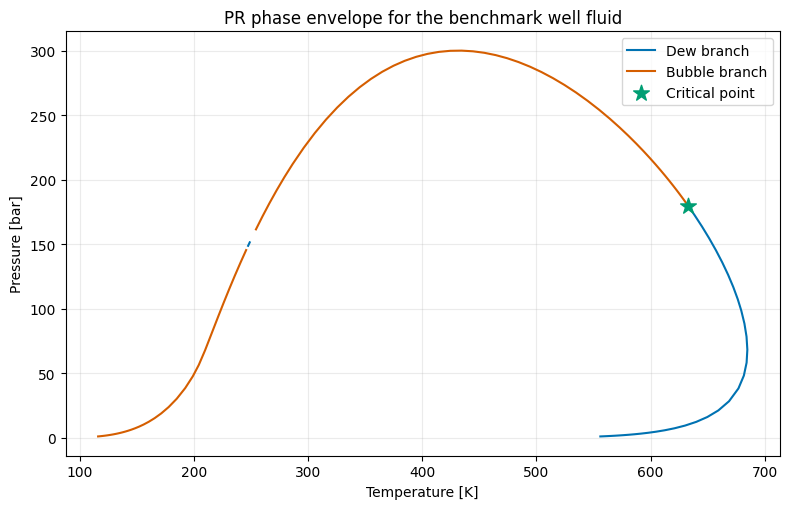

,Point,Temperature [K],Pressure [bara]
0,Cricondenbar,434.472,300.172
1,Cricondentherm,684.626,68.384
2,Critical point,632.828,179.840


In [6]:
phase_envelope_operations = neqsim.thermodynamicoperations.ThermodynamicOperations(
    wellfluid.clone()
)
phase_envelope_operations.calcPTphaseEnvelope()
phase_envelope = phase_envelope_operations.getOperation()

dew_temperature_k = np.asarray(list(phase_envelope.get("dewT")), dtype=float)
dew_pressure_bar = np.asarray(list(phase_envelope.get("dewP")), dtype=float)
bubble_temperature_k = np.asarray(list(phase_envelope.get("bubT")), dtype=float)
bubble_pressure_bar = np.asarray(list(phase_envelope.get("bubP")), dtype=float)
critical_point = np.asarray(list(phase_envelope.get("criticalPoint1")), dtype=float)
cricondenbar = np.asarray(list(phase_envelope.get("cricondenbar")), dtype=float)
cricondentherm = np.asarray(list(phase_envelope.get("cricondentherm")), dtype=float)

figure, axis = plt.subplots(figsize=(8.0, 5.2))
axis.plot(dew_temperature_k, dew_pressure_bar, color="#0072B2", label="Dew branch")
axis.plot(
    bubble_temperature_k,
    bubble_pressure_bar,
    color="#D55E00",
    label="Bubble branch",
)
axis.scatter(
    critical_point[0],
    critical_point[1],
    color="#009E73",
    marker="*",
    s=140,
    label="Critical point",
    zorder=4,
)
axis.set(
    title="PR phase envelope for the benchmark well fluid",
    xlabel="Temperature [K]",
    ylabel="Pressure [bar]",
)
axis.grid(alpha=0.25)
axis.legend()
figure.tight_layout()
plt.show()

envelope_summary = pd.DataFrame(
    {
        "Point": ["Cricondenbar", "Cricondentherm", "Critical point"],
        "Temperature [K]": [cricondenbar[0], cricondentherm[0], critical_point[0]],
        "Pressure [bara]": [cricondenbar[1], cricondentherm[1], critical_point[1]],
    }
)
assert np.isfinite(envelope_summary.iloc[:, 1:].to_numpy()).all()
envelope_summary.round(3)


## 3. Build the connected NeqSim process model

Three pressure stages stabilize the oil. Flash gas is cooled, scrubbed, recompressed, and mixed
upstream; condensed liquids are recycled to the separation train. Export gas is boosted, cooled,
and split from fuel gas, while stabilized oil is cooled and pumped.

The total mass-closure residual used below is

$$
\epsilon_m = 100\frac{\dot{m}_{feed}-\sum_j\dot{m}_{product,j}}{\dot{m}_{feed}}
$$

where every mass flow $\dot{m}$ is in kilograms per hour and $j$ covers fuel gas, export gas,
and export oil. A residual close to zero verifies overall conservation; it does not independently
prove that every unit model or product specification is correct.

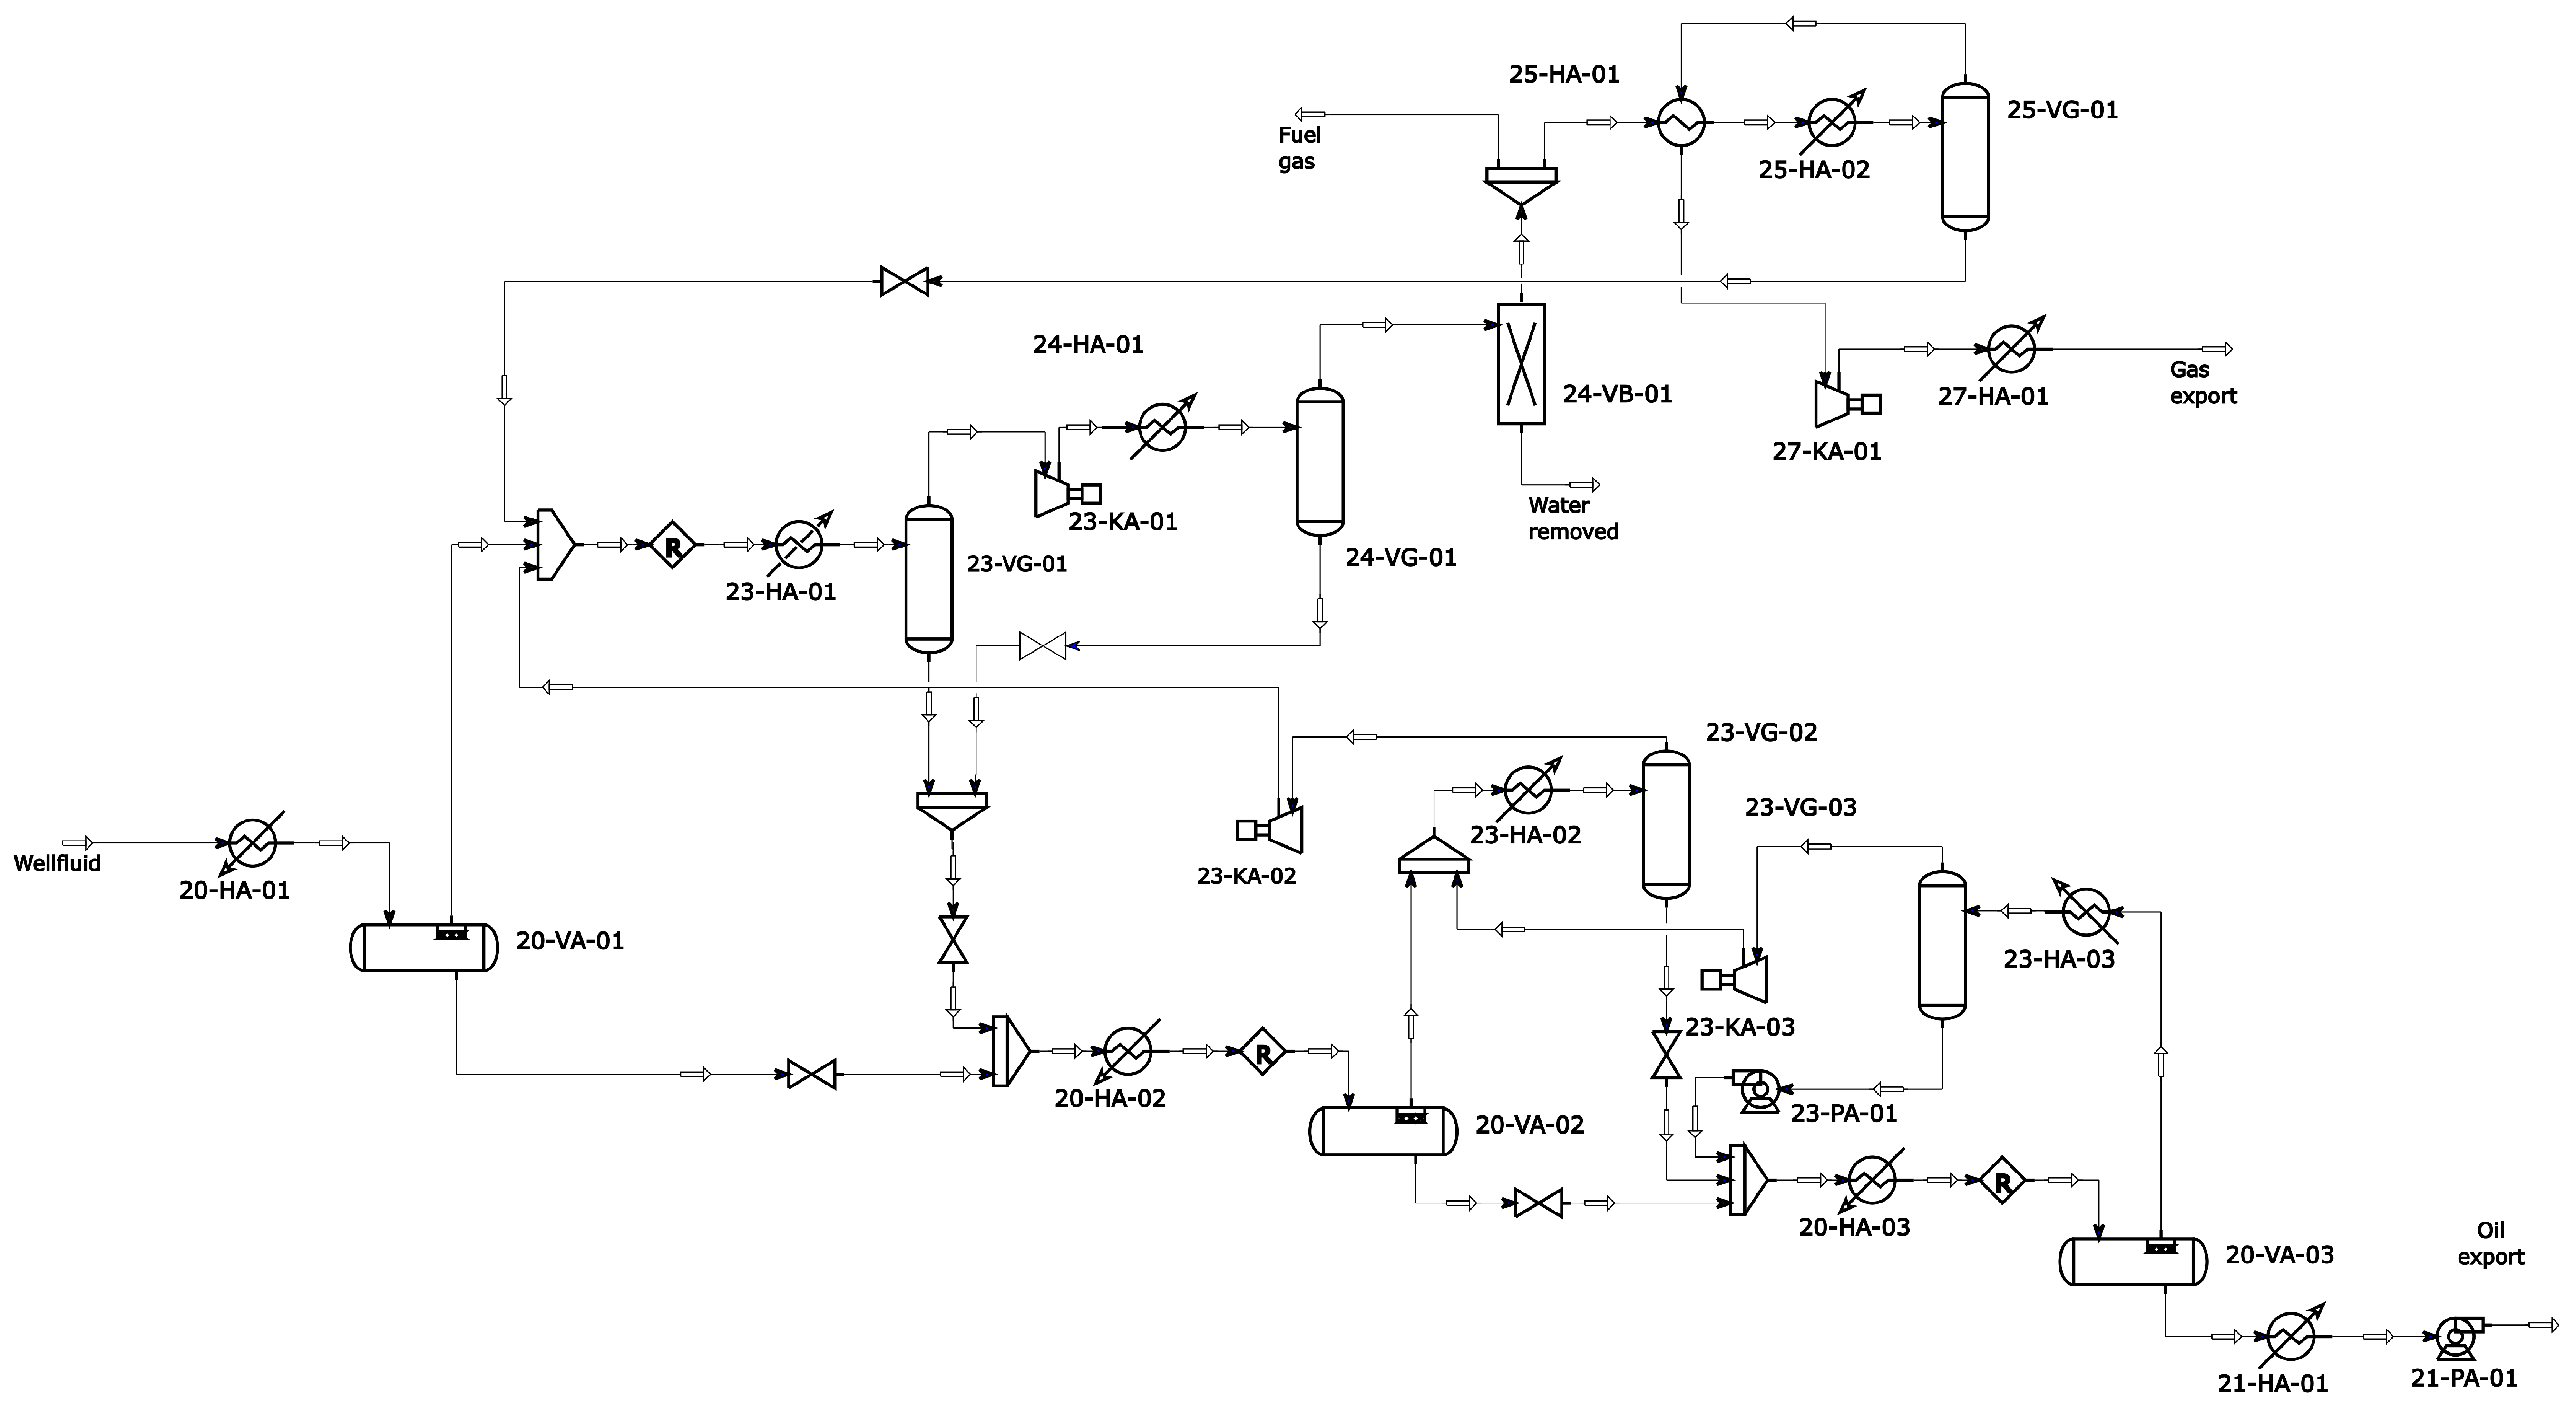

*Published process topology from Andreasen (2020), Figure 1, CC BY 4.0. The current NeqSim model retains the three separators, recompression train, condensate recycles, cold process, oil export, gas export, and fuel-gas split shown here.*

In [7]:
import json
from typing import Optional

from pydantic import Field, field_validator
from pydantic.dataclasses import dataclass


@dataclass
class ProcessInput:
    """Validated operating conditions for the offshore separation process."""

    feed_rate: float = Field(gt=0.0, title="Feed rate [kmol/h]")
    molar_composition: list[float] = Field(title="Feed composition [mole fraction]")
    Psep1: float = Field(ge=0.0, le=100.0, title="Stage 1 pressure [barg]")
    Tsep1: float = Field(ge=0.0, le=100.0, title="Stage 1 temperature [degC]")
    Psep2: float = Field(ge=0.0, le=100.0, title="Stage 2 pressure [barg]")
    Tsep2: float = Field(ge=0.0, le=100.0, title="Stage 2 temperature [degC]")
    Psep3: float = Field(ge=0.0, le=100.0, title="Stage 3 pressure [barg]")
    Tsep3: float = Field(ge=0.0, le=100.0, title="Stage 3 temperature [degC]")
    Tscrub1: float = Field(ge=0.0, le=100.0, title="LP scrubber temperature [degC]")
    Tscrub2: float = Field(ge=0.0, le=100.0, title="MP scrubber temperature [degC]")
    Tscrub3: float = Field(ge=0.0, le=100.0, title="HP scrubber temperature [degC]")
    Tscrub4: float = Field(ge=0.0, le=100.0, title="Export scrubber temperature [degC]")
    Pcomp1: float = Field(ge=0.0, le=150.0, title="Booster discharge pressure [barg]")
    Trefig: float = Field(ge=-20.0, le=100.0, title="Refrigeration temperature [degC]")
    P_oil_export: float = Field(ge=0.0, le=200.0, title="Oil export pressure [barg]")
    T_oil_export: float = Field(ge=0.0, le=100.0, title="Oil export temperature [degC]")
    P_gas_export: float = Field(ge=0.0, le=300.0, title="Gas export pressure [barg]")
    T_gas_export: float = Field(ge=0.0, le=100.0, title="Gas export temperature [degC]")
    dP_20_HA_01: float = Field(ge=0.0, le=10.0, title="20-HA-01 drop [bar]")
    dP_20_HA_02: float = Field(ge=0.0, le=10.0, title="20-HA-02 drop [bar]")
    dP_20_HA_03: float = Field(ge=0.0, le=10.0, title="20-HA-03 drop [bar]")
    dP_21_HA_01: float = Field(ge=0.0, le=10.0, title="21-HA-01 drop [bar]")
    dP_23_HA_01: float = Field(ge=0.0, le=10.0, title="23-HA-01 drop [bar]")
    dP_23_HA_02: float = Field(ge=0.0, le=10.0, title="23-HA-02 drop [bar]")
    dP_23_HA_03: float = Field(ge=0.0, le=10.0, title="23-HA-03 drop [bar]")
    dP_24_HA_01: float = Field(ge=0.0, le=10.0, title="24-HA-01 drop [bar]")
    dP_25_HA_01: float = Field(ge=0.0, le=10.0, title="25-HA-01 drop [bar]")
    dP_25_HA_02: float = Field(ge=0.0, le=10.0, title="25-HA-02 drop [bar]")
    dP_27_HA_01: float = Field(ge=0.0, le=10.0, title="27-HA-01 drop [bar]")

    @field_validator("molar_composition")
    @classmethod
    def check_molar_composition(cls, values):
        if len(values) != 17:
            raise ValueError("The process fluid requires exactly 17 components.")
        if not np.isclose(sum(values), 1.0, atol=1.0e-10):
            raise ValueError("Mole fractions must sum to one.")
        return values


@dataclass
class ProcessOutput:
    """Concise simulation result plus the complete native JSON report."""

    mass_balance_percent: Optional[float] = None
    results: Optional[dict] = None


#### Process object graph

The next cell contains the preserved process factory. It deliberately creates all
streams and equipment anew so sampling and optimization remain independent.

In [8]:
def getprocess():
    """
    Create and return a NeqSim oil process object using default or
    the shared well-fluid basis. This function demonstrates the
    general structure of a multi-stage oil and gas separation process
    with scrubbing, compressing, cooling, and pumping steps.

    Returns:
        A NeqSim ProcessSystem object representing the oil and gas
        separation process.
    """
    # Create a reference fluid (ensure 'wellfluid' is defined or created externally)
    wellstream = neqsim.process.equipment.stream.Stream("well stream", wellfluid.clone())
    wellstream.setTemperature(60.0, "C")
    wellstream.setPressure(33.01, "bara")

    # Heater
    well_stream_cooler = neqsim.process.equipment.heatexchanger.Heater("20-HA-01", wellstream)

    # First-stage separator
    first_stage_separator = neqsim.process.equipment.separator.ThreePhaseSeparator(
        "20-VA-01", well_stream_cooler.getOutStream()
    )

    # Throttling valve from first-stage separator oil out
    oilvalve1 = neqsim.process.equipment.valve.ThrottlingValve(
        "VLV-100", first_stage_separator.getOilOutStream()
    )

    # Named numerical recycle destinations used by the current Java reference.
    # These Stream objects are convergence utilities, not physical equipment.
    dew_point_liquid_reflux_1 = wellstream.clone()
    dew_point_liquid_reflux_1.setName("dew point liquid reflux 1")
    dew_point_liquid_reflux_1.setFlowRate(10.0, "kg/hr")
    dew_point_liquid_reflux_1.setPressure(9.5, "bara")

    dew_point_liquid_reflux_2 = wellstream.clone()
    dew_point_liquid_reflux_2.setName("dew point liquid reflux 2")
    dew_point_liquid_reflux_2.setFlowRate(10.0, "kg/hr")
    dew_point_liquid_reflux_2.setPressure(9.5, "bara")

    # Mixer for second-stage inlet
    oil_2nd_stage_mixer = neqsim.process.equipment.mixer.Mixer("MIX-101")
    oil_2nd_stage_mixer.addStream(oilvalve1.getOutStream())
    oil_2nd_stage_mixer.addStream(dew_point_liquid_reflux_1)
    oil_2nd_stage_mixer.addStream(dew_point_liquid_reflux_2)

    # Heater
    oilHeaterFromFirstStage = neqsim.process.equipment.heatexchanger.Heater(
        "20-HA-02", oil_2nd_stage_mixer.getOutStream()
    )

    # Second-stage separator
    seccond_stage_separator = neqsim.process.equipment.separator.ThreePhaseSeparator(
        "20-VA-02", oilHeaterFromFirstStage.getOutStream()
    )

    # Throttling valve from second-stage separator oil out
    oilvalve2 = neqsim.process.equipment.valve.ThrottlingValve(
        "VLV-102", seccond_stage_separator.getOilOutStream()
    )

    # Reflux from well stream (for demonstration, setFlowRate is trivial)
    oilreflux = wellstream.clone()
    oilreflux.setName("third stage reflux")
    oilreflux.setFlowRate(1e-6, "kg/hr")

    # Mixer for third-stage inlet
    thirdstageoilmixer = neqsim.process.equipment.mixer.Mixer("MIX-102")
    thirdstageoilmixer.addStream(oilvalve2.getOutStream())
    thirdstageoilmixer.addStream(oilreflux)

    # Heater
    oilHeaterFromSeccondStage = neqsim.process.equipment.heatexchanger.Heater(
        "20-HA-03", thirdstageoilmixer.getOutletStream()
    )

    # Third-stage separator
    third_stage_separator = neqsim.process.equipment.separator.ThreePhaseSeparator(
        "20-VA-03", oilHeaterFromSeccondStage.getOutStream()
    )

    # Cooler
    firstStageCooler = neqsim.process.equipment.heatexchanger.Cooler(
        "23-HA-03", third_stage_separator.getGasOutStream()
    )

    # Scrubber
    firstStageScrubber = neqsim.process.equipment.separator.Separator(
        "23-VG-03", firstStageCooler.getOutStream()
    )

    # Pump
    firststagescrubberpump = neqsim.process.equipment.pump.Pump(
        "23-PA-01", firstStageScrubber.getLiquidOutStream()
    )

    # Recycle
    lp_recycle = neqsim.process.equipment.util.Recycle("LP oil recycle")
    lp_recycle.addStream(firststagescrubberpump.getOutStream())
    lp_recycle.setOutletStream(oilreflux)
    lp_recycle.setTolerance(1e-6)

    # First-stage recompressor
    first_stage_recompressor = neqsim.process.equipment.compressor.Compressor(
        "23-KA-03", firstStageScrubber.getGasOutStream()
    )
    first_stage_recompressor.setIsentropicEfficiency(0.75)

    # Mixer combining first-stage recompressor gas and second-stage separator gas
    firststagegasmixer = neqsim.process.equipment.mixer.Mixer("MIX-103")
    firststagegasmixer.addStream(first_stage_recompressor.getOutStream())
    firststagegasmixer.addStream(seccond_stage_separator.getGasOutStream())

    # Second-stage cooler
    seccond_stage_cooler = neqsim.process.equipment.heatexchanger.Cooler(
        "23-HA-02", firststagegasmixer.getOutStream()
    )

    # Second-stage scrubber
    seccond_stage_scrubber = neqsim.process.equipment.separator.Separator(
        "23-VG-02", seccond_stage_cooler.getOutStream()
    )

    # Add second-stage scrubber liquid to third-stage oil mixer
    thirdstageoilmixer.addStream(seccond_stage_scrubber.getLiquidOutStream())

    # Second-stage recompressor
    seccond_stage_recompressor = neqsim.process.equipment.compressor.Compressor(
        "23-KA-02", seccond_stage_scrubber.getGasOutStream()
    )
    seccond_stage_recompressor.setIsentropicEfficiency(0.75)

    # Mixer combining second-stage recompressor gas and first-stage separator gas
    exportgasmixer = neqsim.process.equipment.mixer.Mixer("MIX-100")
    exportgasmixer.addStream(seccond_stage_recompressor.getOutStream())
    exportgasmixer.addStream(first_stage_separator.getGasOutStream())

    # Dew point cooler
    dew_point_cooler = neqsim.process.equipment.heatexchanger.Cooler(
        "23-HA-01", exportgasmixer.getOutStream()
    )

    # Dew point scrubber
    dew_point_scrubber = neqsim.process.equipment.separator.Separator(
        "23-VG-01", dew_point_cooler.getOutStream()
    )

    # Make the first dew-point liquid return explicit for stable convergence.
    dew_point_recycle_1 = neqsim.process.equipment.util.Recycle("dew point recycle 1")
    dew_point_recycle_1.addStream(dew_point_scrubber.getLiquidOutStream())
    dew_point_recycle_1.setOutletStream(dew_point_liquid_reflux_1)
    dew_point_recycle_1.setTolerance(1e-6)

    # First stage export compressor
    first_stage_export_compressor = neqsim.process.equipment.compressor.Compressor(
        "23-KA-01", dew_point_scrubber.getGasOutStream()
    )
    first_stage_export_compressor.setIsentropicEfficiency(0.75)

    # Cooler after first stage export compressor
    dew_point_cooler2 = neqsim.process.equipment.heatexchanger.Cooler(
        "24-HA-01", first_stage_export_compressor.getOutStream()
    )

    # Scrubber after second dew point cooler
    dew_point_scrubber2 = neqsim.process.equipment.separator.Separator(
        "24-VG-01", dew_point_cooler2.getOutStream()
    )

    # Make the second dew-point liquid return explicit for stable convergence.
    dew_point_recycle_2 = neqsim.process.equipment.util.Recycle("dew point recycle 2")
    dew_point_recycle_2.addStream(dew_point_scrubber2.getLiquidOutStream())
    dew_point_recycle_2.setOutletStream(dew_point_liquid_reflux_2)
    dew_point_recycle_2.setTolerance(1e-6)

    # Gas splitter
    gas_splitter = neqsim.process.equipment.splitter.Splitter(
        "splitter", dew_point_scrubber2.getGasOutStream()
    )
    gas_splitter.setSplitNumber(2)
    gas_splitter.setFlowRates([-1, 2966.0], "kg/hr")  # Example usage

    # Fuel gas stream
    fuel_gas = gas_splitter.getSplitStream(1)
    fuel_gas.setName("fuel gas")

    # Heat exchanger
    gas_heatexchanger = neqsim.process.equipment.heatexchanger.HeatExchanger(
        "25-HA-01", gas_splitter.getSplitStream(0)
    )
    gas_heatexchanger.setGuessOutTemperature(273.15 + 15.0)
    gas_heatexchanger.setUAvalue(800e3)

    # Dew point cooler #3
    dew_point_cooler3 = neqsim.process.equipment.heatexchanger.Cooler(
        "25-HA-02", gas_heatexchanger.getOutStream(0)
    )

    # Dew point scrubber #3
    dew_point_scrubber3 = neqsim.process.equipment.separator.Separator(
        "25-VG-01", dew_point_cooler3.getOutStream()
    )

    # Add dew point scrubber #3 liquid to the export gas mixer
    exportgasmixer.addStream(dew_point_scrubber3.getLiquidOutStream())

    # Set feed for the heat exchanger
    gas_heatexchanger.setFeedStream(1, dew_point_scrubber3.getGasOutStream())

    # Second-stage export compressor
    seccond_stage_export_compressor = neqsim.process.equipment.compressor.Compressor(
        "27-KA-01", gas_heatexchanger.getOutStream(1)
    )
    seccond_stage_export_compressor.setIsentropicEfficiency(0.75)

    # Cooler after second-stage export compressor
    export_compressor_cooler = neqsim.process.equipment.heatexchanger.Cooler(
        "27-HA-01", seccond_stage_export_compressor.getOutStream()
    )

    # Final export gas
    export_gas = export_compressor_cooler.getOutStream()
    export_gas.setName("export gas")

    # Export oil cooler
    export_oil_cooler = neqsim.process.equipment.heatexchanger.Cooler(
        "21-HA-01", third_stage_separator.getOilOutStream()
    )

    # Export oil pump
    export_oil_pump = neqsim.process.equipment.pump.Pump(
        "21-PA-01", export_oil_cooler.getOutStream()
    )
    export_oil = export_oil_pump.getOutStream()
    export_oil.setName("export oil")

    # Create a process system
    oilprocess = neqsim.process.processmodel.ProcessSystem()
    oilprocess.add(wellstream)
    oilprocess.add(well_stream_cooler)
    oilprocess.add(first_stage_separator)
    oilprocess.add(oilvalve1)
    oilprocess.add(dew_point_liquid_reflux_1)
    oilprocess.add(dew_point_liquid_reflux_2)
    oilprocess.add(oil_2nd_stage_mixer)
    oilprocess.add(oilHeaterFromFirstStage)
    oilprocess.add(seccond_stage_separator)
    oilprocess.add(oilvalve2)
    oilprocess.add(oilreflux)
    oilprocess.add(thirdstageoilmixer)
    oilprocess.add(oilHeaterFromSeccondStage)
    oilprocess.add(third_stage_separator)
    oilprocess.add(firstStageCooler)
    oilprocess.add(firstStageScrubber)
    oilprocess.add(firststagescrubberpump)
    oilprocess.add(lp_recycle)
    oilprocess.add(first_stage_recompressor)
    oilprocess.add(firststagegasmixer)
    oilprocess.add(seccond_stage_cooler)
    oilprocess.add(seccond_stage_scrubber)
    oilprocess.add(seccond_stage_recompressor)
    oilprocess.add(exportgasmixer)
    oilprocess.add(dew_point_cooler)
    oilprocess.add(dew_point_scrubber)
    oilprocess.add(dew_point_recycle_1)
    oilprocess.add(first_stage_export_compressor)
    oilprocess.add(dew_point_cooler2)
    oilprocess.add(dew_point_scrubber2)
    oilprocess.add(dew_point_recycle_2)
    oilprocess.add(gas_splitter)
    oilprocess.add(gas_heatexchanger)
    oilprocess.add(dew_point_cooler3)
    oilprocess.add(dew_point_scrubber3)
    oilprocess.add(seccond_stage_export_compressor)
    oilprocess.add(export_compressor_cooler)
    oilprocess.add(export_oil_cooler)
    oilprocess.add(export_oil_pump)
    oilprocess.add(export_gas)
    oilprocess.add(export_oil)
    oilprocess.add(fuel_gas)

    return oilprocess


In [9]:
def updateinput(process, local_input):
    """Apply validated operating conditions without hiding missing-unit errors."""

    process.getUnit("well stream").setFlowRate(
        local_input.feed_rate * 1.0e3 / 3600.0,
        "mol/sec",
    )
    process.getUnit("well stream").getFluid().setMolarComposition(local_input.molar_composition)
    process.getUnit("well stream").setPressure(
        local_input.Psep1 + local_input.dP_20_HA_01,
        "barg",
    )
    process.getUnit("well stream").setTemperature(60.0, "C")

    process.getUnit("20-HA-01").setOutTemperature(local_input.Tsep1, "C")
    process.getUnit("20-HA-01").setOutPressure(local_input.Psep1, "barg")
    process.getUnit("VLV-100").setOutletPressure(
        local_input.Psep2 + local_input.dP_20_HA_02,
        "barg",
    )
    process.getUnit("20-HA-02").setOutTemperature(local_input.Tsep2, "C")
    process.getUnit("20-HA-02").setOutPressure(local_input.Psep2, "barg")
    process.getUnit("VLV-102").setOutletPressure(
        local_input.Psep3 + local_input.dP_20_HA_03,
        "barg",
    )
    process.getUnit("20-HA-03").setOutTemperature(local_input.Tsep3, "C")
    process.getUnit("20-HA-03").setOutPressure(local_input.Psep3, "barg")

    process.getUnit("23-HA-03").setOutTemperature(local_input.Tscrub1, "C")
    process.getUnit("23-HA-03").setOutPressure(
        local_input.Psep3 - local_input.dP_23_HA_03,
        "barg",
    )
    process.getUnit("23-PA-01").setPressure(
        local_input.Psep3 + local_input.dP_20_HA_03,
        "barg",
    )
    process.getUnit("23-KA-03").setOutletPressure(local_input.Psep2, "barg")
    process.getUnit("23-HA-02").setOutTemperature(local_input.Tscrub2, "C")
    process.getUnit("23-HA-02").setOutPressure(
        local_input.Psep2 - local_input.dP_23_HA_02,
        "barg",
    )
    process.getUnit("23-KA-02").setOutletPressure(local_input.Psep1, "barg")

    process.getUnit("23-HA-01").setOutTemperature(local_input.Tscrub3, "C")
    process.getUnit("23-HA-01").setOutPressure(
        local_input.Psep1 - local_input.dP_23_HA_01,
        "barg",
    )
    process.getUnit("23-KA-01").setOutletPressure(local_input.Pcomp1, "barg")
    process.getUnit("24-HA-01").setOutTemperature(local_input.Tscrub4, "C")
    process.getUnit("24-HA-01").setOutPressure(
        local_input.Pcomp1 - local_input.dP_24_HA_01,
        "barg",
    )

    process.getUnit("25-HA-02").setOutTemperature(local_input.Trefig, "C")
    process.getUnit("25-HA-02").setOutPressure(
        local_input.Pcomp1 - local_input.dP_25_HA_01 - local_input.dP_25_HA_02,
        "barg",
    )
    process.getUnit("27-KA-01").setOutletPressure(
        local_input.P_gas_export,
        "barg",
    )
    process.getUnit("27-HA-01").setOutTemperature(
        local_input.T_gas_export,
        "C",
    )
    process.getUnit("27-HA-01").setOutPressure(
        local_input.P_gas_export - local_input.dP_27_HA_01,
        "barg",
    )

    process.getUnit("21-HA-01").setOutTemperature(
        local_input.T_oil_export,
        "C",
    )
    process.getUnit("21-HA-01").setOutPressure(
        local_input.Psep3 - local_input.dP_21_HA_01,
        "barg",
    )
    process.getUnit("21-PA-01").setOutletPressure(
        local_input.P_oil_export + 1.01325,
        "bara",
    )


def process_mass_balance_percent(process):
    feed_mass = process.getUnit("well stream").getFlowRate("kg/hr")
    product_mass = sum(
        process.getUnit(name).getFlowRate("kg/hr")
        for name in ("fuel gas", "export gas", "export oil")
    )
    return 100.0 * (feed_mass - product_mass) / feed_mass


def getoutput(process):
    report_text = str(neqsim.process.util.report.Report(process).generateJsonReport())
    return {
        "results": json.loads(report_text),
        "mass_balance_percent": process_mass_balance_percent(process),
    }


def extract_process_metrics(process):
    compressor_names = ("23-KA-01", "23-KA-02", "23-KA-03", "27-KA-01")
    compressor_power_kw = sum(process.getUnit(name).getPower("kW") for name in compressor_names)
    pump_power_kw = process.getUnit("21-PA-01").getPower("kW")
    return {
        "total_power_kw": compressor_power_kw + pump_power_kw,
        "oil_export_m3_day": process.getUnit("export oil").getFlowRate("m3/hr") * 24.0,
        "gas_export_msm3_day": process.getUnit("export gas").getFlowRate("MSm3/day"),
        "mass_balance_percent": process_mass_balance_percent(process),
    }


def run_simulation(process, input_params, timeout_seconds=120, runAsThread=False):
    validated_input = ProcessInput(**input_params)
    updateinput(process, validated_input)

    if runAsThread:
        return process.runAsThread(), process

    calculation_thread = process.runAsThread()
    calculation_thread.join(timeout_seconds * 1000)
    if calculation_thread.isAlive():
        calculation_thread.interrupt()
        calculation_thread.join()
        raise TimeoutError(f"Process calculation exceeded {timeout_seconds} seconds.")

    return ProcessOutput(**getoutput(process))


### Process factory and operating-condition contract

The factory creates a fresh object graph for every independent case. This prevents warm recycle
states or mutable stream objects from leaking between samples. The input updater intentionally
fails if a named unit is absent. It also corrects three previously hidden pressure-drop mappings:
`23-HA-03`, `25-HA-02`, and the final gas export cooler now use their own specified pressure drops
and the gas-export pressure rather than unrelated fields.

In [10]:
process1 = getprocess()
required_units = [
    "well stream",
    "20-VA-01",
    "20-VA-02",
    "20-VA-03",
    "23-KA-03",
    "23-KA-02",
    "23-KA-01",
    "27-KA-01",
    "LP oil recycle",
    "dew point recycle 1",
    "dew point recycle 2",
    "export gas",
    "export oil",
    "fuel gas",
]
missing_units = [name for name in required_units if process1.getUnit(name) is None]
assert not missing_units, f"Missing process units: {missing_units}"

pd.DataFrame(
    {
        "Model check": ["Required named units", "Missing units"],
        "Value": [len(required_units), len(missing_units)],
    }
)


,Model check,Value
0,Required named units,14
1,Missing units,0


### Base operating case

The base case preserves the original feed rate and operating conditions. Gauge pressures are
converted by the NeqSim unit-aware setters. Every later scenario begins from this dictionary and
changes only the explicitly sampled or optimized fields.

In [11]:
import time

inputparam = {
    "feed_rate": 8000.0,
    "molar_composition": list(wellfluid.getMolarComposition()),
    "Tsep1": 70.0,
    "Psep1": 31.5,
    "Psep2": 8.0,
    "Psep3": 1.5,
    "Tsep2": 68.2,
    "Tsep3": 65.0,
    "Tscrub1": 32.0,
    "Tscrub2": 32.0,
    "Tscrub3": 32.0,
    "Tscrub4": 30.0,
    "Pcomp1": 90.0,
    "Trefig": 10.0,
    "P_oil_export": 60.0,
    "T_oil_export": 48.5,
    "P_gas_export": 188.6,
    "T_gas_export": 40.0,
    "dP_20_HA_01": 0.5,
    "dP_20_HA_02": 0.5,
    "dP_20_HA_03": 0.5,
    "dP_21_HA_01": 0.5,
    "dP_23_HA_01": 0.3,
    "dP_23_HA_02": 1.0,
    "dP_23_HA_03": 1.0,
    "dP_24_HA_01": 1.0,
    "dP_25_HA_01": 0.5,
    "dP_25_HA_02": 0.5,
    "dP_27_HA_01": 0.0,
}

base_start = time.perf_counter()
results = run_simulation(process=process1, input_params=inputparam)
time_for_one_process_sim = time.perf_counter() - base_start
base_metrics = extract_process_metrics(process1)

assert results is not None
assert abs(results.mass_balance_percent) < 1.0e-2
print(f"Base case completed in {time_for_one_process_sim:.2f} s")
pd.DataFrame([base_metrics]).round(6)


Base case completed in 3.90 s


,total_power_kw,oil_export_m3_day,gas_export_msm3_day,mass_balance_percent
0,10431.534102,19130.542443,2.900748,0.000076


The base case converges with a small overall mass residual. Subsequent tables reuse the
solved object and do not trigger hidden reruns.

### Fresh model-generated PFD and P&ID review workflow

The solved `process1` object is the single canonical plant for both profiles. The PFD reports
process topology, operating results, stream identities, balances, and area/sheet structure. The
distinct P&ID is a **review-required teaching proposal** that adds explicit nozzles, valves,
reducers, instruments, control signals, and declared isolation/drain/vent/relief interfaces from
source-linked engineering registers.

The earlier embedded illustration and preserved Graphviz output remain historical context; neither
is acceptance evidence. To match the accepted reusable Java reference, `getprocess()` now names its
three numerical recycle utilities and uses two named placeholder streams as their convergence
destinations. This makes the existing liquid returns explicit without adding physical process
equipment. The illustrated `24-VB-01` is absent from `getprocess()` and is not created.
Missing line classes, piping specifications, design pressure/temperature, materials, valve failure
positions, instrument ranges, alarm/trip set points, hazardous-area data, relief sizing/disposal,
drain/vent destinations, revision approvals, and accountable discipline sign-off remain explicit
project metadata gaps. Therefore these outputs claim neither completed safety design nor ISO 10628
or ANSI/ISA-5.1 conformance, certification, construction fitness, or engineering approval.

An independently reconstructed and solved plant must regenerate every delivered byte identically.
The renderer's completed-scene diagnostics are retained as a fail-visible review gate: warnings
block visual acceptance and publication approval, but do not prevent this teaching proposal from
showing the exact generated sheets and their accountable defect inventory.
Native DEXPI 2.0 Plant/Process outputs and the separately labelled Proteus 4.1 compatibility
companion are intentionally distinct; schema checks are not named-CAE round-trip qualification.

In [12]:
import collections
import json
from IPython.display import FileLink, Markdown, SVG, display

diagram_output_directory = Path("comparesimulations2-engineering-diagrams-v1")
if diagram_output_directory.exists():
    raise RuntimeError(
        f"Clean execution requires a new output directory: {diagram_output_directory.resolve()}"
    )

ReferenceWorkflow = jpype.JClass(
    "neqsim.process.examples.Comparesimulations2EngineeringDiagramReference"
)
JavaPaths = jpype.JClass("java.nio.file.Paths")
diagram_report = ReferenceWorkflow.deliver(
    process1,
    JavaPaths.get(str(diagram_output_directory.resolve())),
)
dual_profile_manifest = json.loads(str(diagram_report.toJson()))

assert process1.getUnit("24-VB-01") is None
assert dual_profile_manifest["pfdContentProfile"] == "PFD"
assert dual_profile_manifest["pidContentProfile"] == "PID"
assert dual_profile_manifest["pfdDexpiInformationModel"] == "DEXPI_2_0_PROCESS"
assert dual_profile_manifest["pidNativeDexpiInformationModel"] == "DEXPI_2_0_PLANT_P_ID"
assert dual_profile_manifest["pidProteusCompatibilityProfile"] == "PROTEUS_4_1"

# Reconstruct and solve the canonical plant independently, then require every
# generated byte (including manifests, SVG, PDF, and exchange companions) to match.
repeat_output_directory = Path("comparesimulations2-engineering-diagrams-repeat")
if repeat_output_directory.exists():
    raise RuntimeError(
        f"Clean execution requires a new output directory: {repeat_output_directory.resolve()}"
    )
repeat_process = getprocess()
repeat_result = run_simulation(repeat_process, inputparam)
assert abs(repeat_result.mass_balance_percent) < 1.0e-2
assert repeat_process.getUnit("24-VB-01") is None
ReferenceWorkflow.deliver(
    repeat_process,
    JavaPaths.get(str(repeat_output_directory.resolve())),
)


def artifact_hashes(root):
    return {
        str(path.relative_to(root)): hashlib.sha256(path.read_bytes()).hexdigest()
        for path in sorted(root.rglob("*"))
        if path.is_file()
    }


primary_artifact_hashes = artifact_hashes(diagram_output_directory)
repeat_artifact_hashes = artifact_hashes(repeat_output_directory)
assert primary_artifact_hashes == repeat_artifact_hashes


def collect_diagnostics(value):
    rows = []
    if isinstance(value, dict):
        if "severity" in value and "code" in value:
            rows.append(value)
        for nested in value.values():
            rows.extend(collect_diagnostics(nested))
    elif isinstance(value, list):
        for nested in value:
            rows.extend(collect_diagnostics(nested))
    return rows


profile_rows = []
profile_fingerprints = {}
expected_warning_counts = {"pfd": 14, "pid": 413}
for profile in ("pfd", "pid"):
    profile_directory = diagram_output_directory / profile
    manifest_path = profile_directory / "delivery-manifest.json"
    profile_manifest = json.loads(manifest_path.read_text())
    renderer_diagnostics = [
        row
        for row in collect_diagnostics(profile_manifest)
        if str(row["code"]).startswith("DIAGRAM_RENDER_")
    ]
    severity_counts = collections.Counter(row["severity"] for row in renderer_diagnostics)
    assert severity_counts["ERROR"] == 0
    assert severity_counts["WARNING"] == expected_warning_counts[profile]
    svg_pages = sorted((profile_directory / "svg").glob("*.svg"))
    assert len(svg_pages) == 4
    assert (profile_directory / "drawing-set.pdf").is_file()
    profile_fingerprints[profile] = profile_manifest["sourceGraphFingerprint"]
    profile_rows.append(
        {
            "Profile": profile.upper(),
            "A1 SVG sheets": len(svg_pages),
            "Renderer warnings": severity_counts["WARNING"],
            "Renderer errors": severity_counts["ERROR"],
            "Visual acceptance": (
                "PASS" if severity_counts["WARNING"] == 0 else "BLOCKED — REVIEW REQUIRED"
            ),
            "Stable regeneration": primary_artifact_hashes == repeat_artifact_hashes,
            "PDF SHA-256": next(
                row["sha256"]
                for row in profile_manifest["artifacts"]
                if row["relativePath"] == "drawing-set.pdf"
            ),
        }
    )

assert profile_fingerprints["pfd"] == profile_fingerprints["pid"]
diagram_acceptance_table = pd.DataFrame(profile_rows)
diagram_acceptance_table

,Profile,A1 SVG sheets,Renderer warnings,Renderer errors,Visual acceptance,Stable regeneration,PDF SHA-256
0,PFD,4,14,0,BLOCKED — REVIEW REQUIRED,True,a8ce98adc76ebd0be59a3b3fa59d7e7df5dc3dd1949b6d...
1,PID,4,413,0,BLOCKED — REVIEW REQUIRED,True,ff5f7a29a33c0ea734a7950d4d6701143739fa3e2aee6c...


## Fresh PFD review set — four A1 sheets

/workspace/scratch/93e2db7bed40/NeqSim-Colab/comparesimulations2-engineering-diagrams-v1/pfd/drawing-set.pdf

### PFD sheet 1: `sheet-pfd-andreasen-001-andreasen-separation-compression-process-system-2f2092b7d75c.svg`

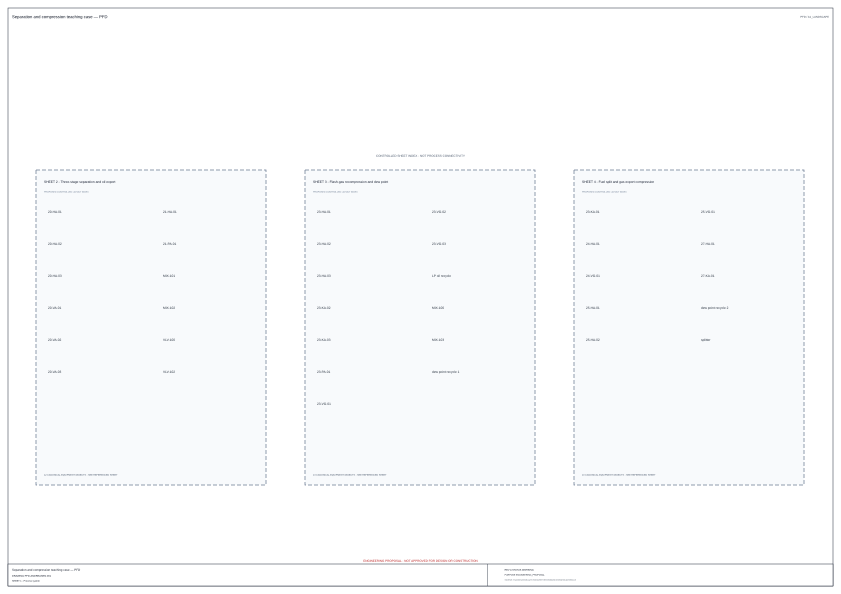

### PFD sheet 2: `sheet-pfd-andreasen-001-export-aacfac77a522.svg`

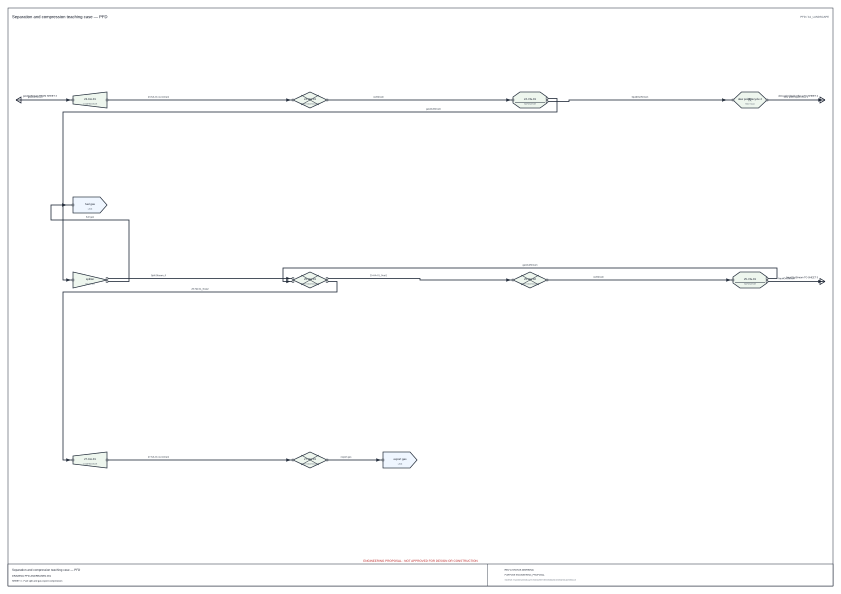

### PFD sheet 3: `sheet-pfd-andreasen-001-recompression-4a1fda4475b1.svg`

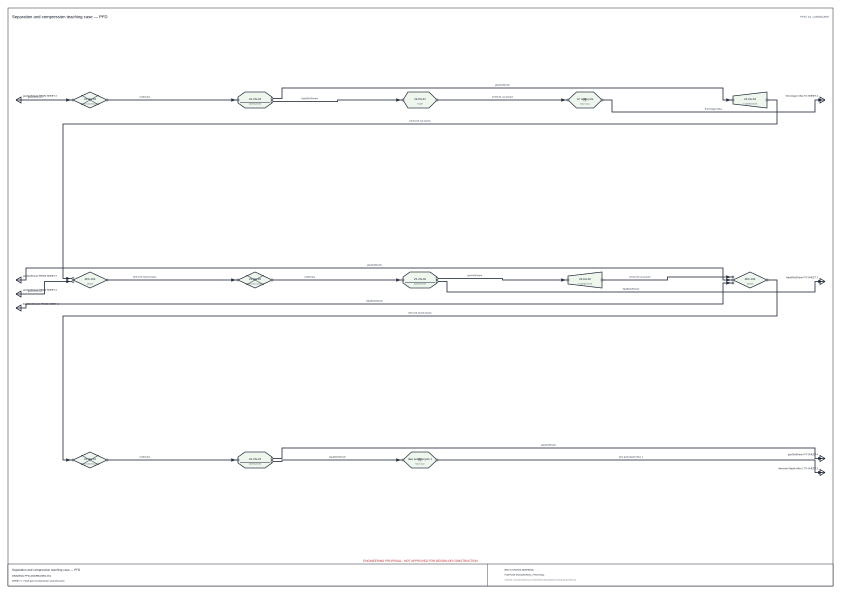

### PFD sheet 4: `sheet-pfd-andreasen-001-separation-dbe20beb7f27.svg`

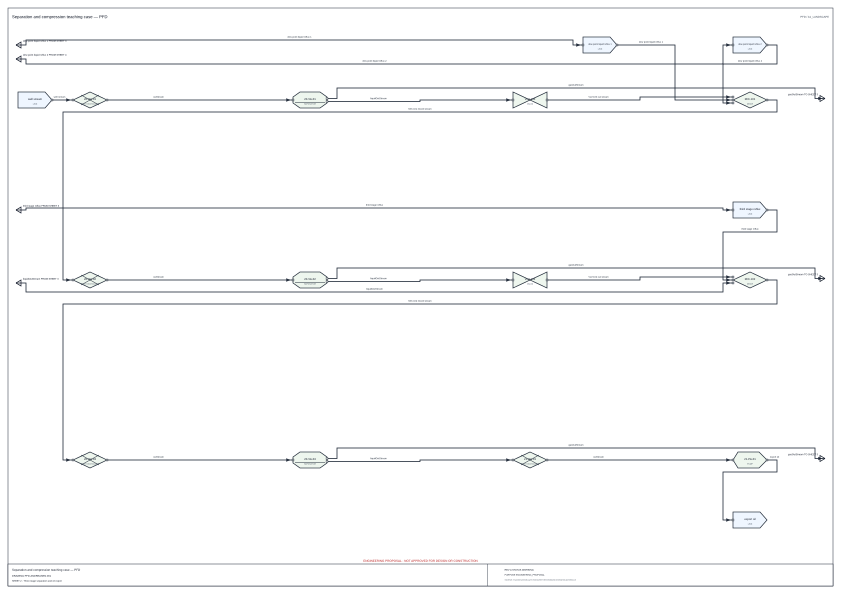

## Fresh PID review set — four A1 sheets

/workspace/scratch/93e2db7bed40/NeqSim-Colab/comparesimulations2-engineering-diagrams-v1/pid/drawing-set.pdf

### PID sheet 1: `sheet-pid-andreasen-001-andreasen-separation-compression-process-system-a7eb8354abad.svg`

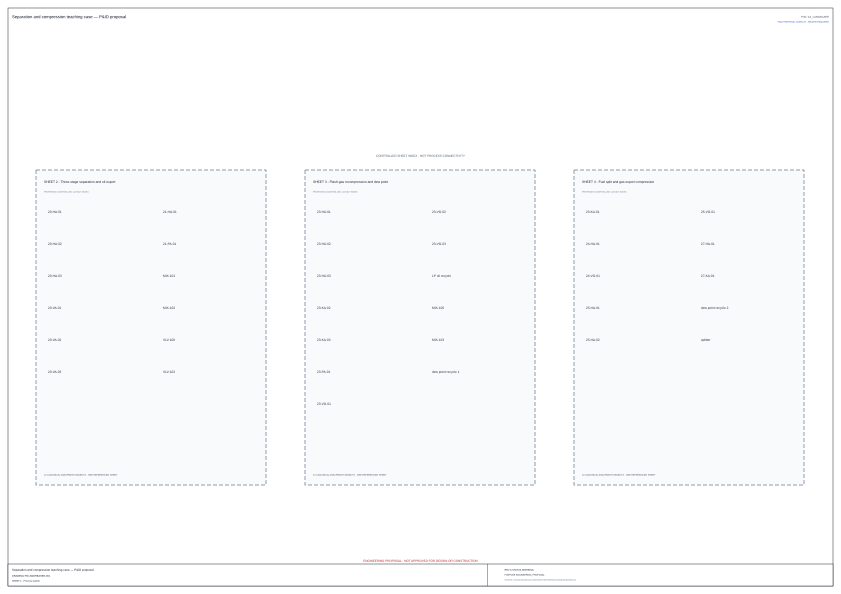

### PID sheet 2: `sheet-pid-andreasen-001-export-4e83a56f46ef.svg`

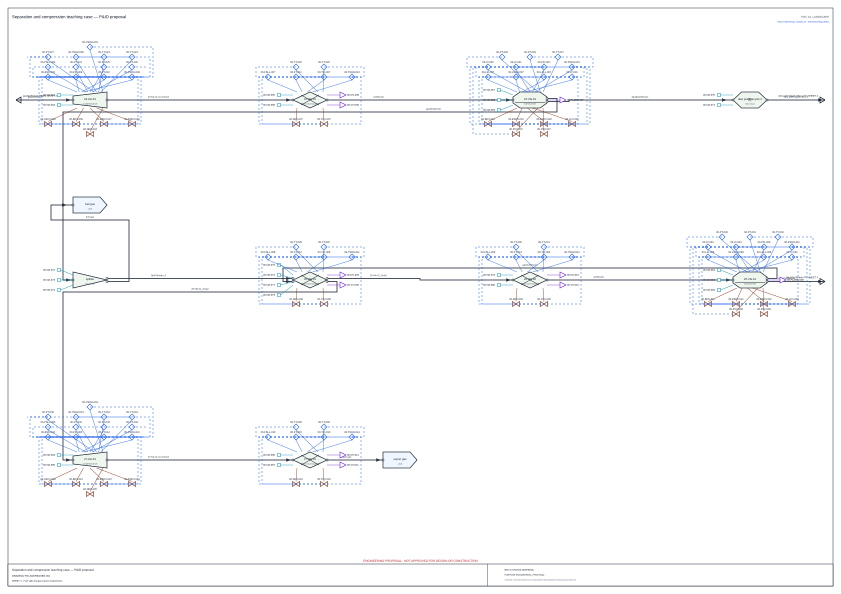

### PID sheet 3: `sheet-pid-andreasen-001-recompression-14d4ae08cbb7.svg`

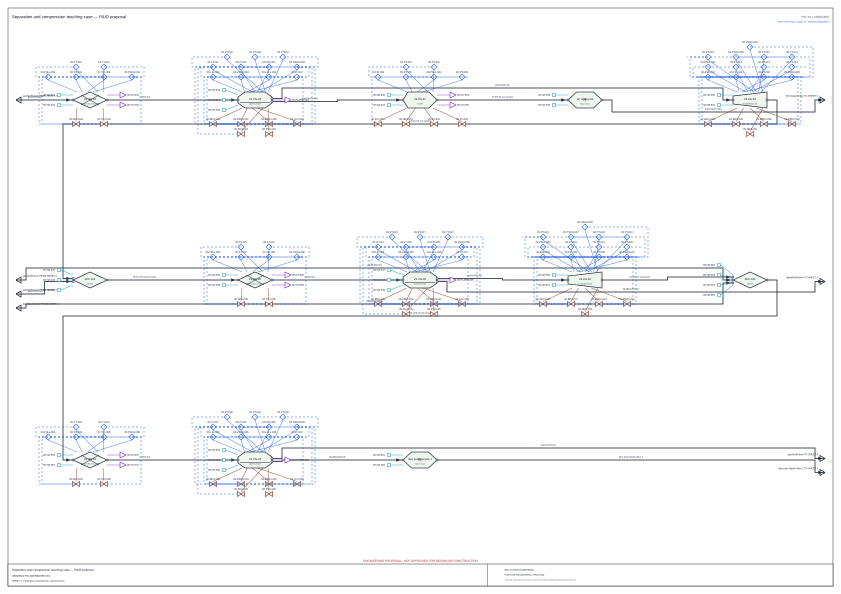

### PID sheet 4: `sheet-pid-andreasen-001-separation-444cd4c04d2d.svg`

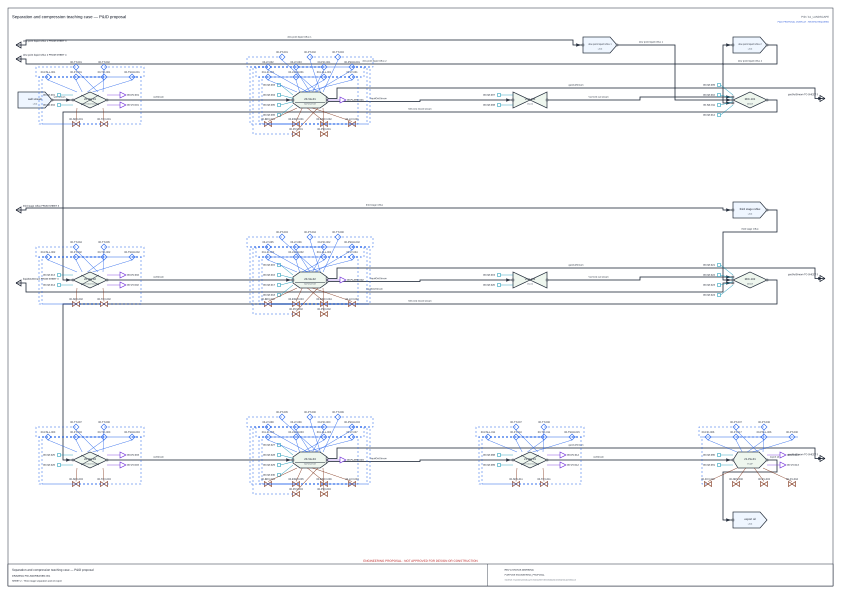

In [13]:
for profile in ("pfd", "pid"):
    profile_directory = diagram_output_directory / profile
    display(Markdown(f"## Fresh {profile.upper()} review set — four A1 sheets"))
    display(FileLink(str(profile_directory / "drawing-set.pdf")))
    for sheet_number, svg_path in enumerate(sorted((profile_directory / "svg").glob("*.svg")), 1):
        display(Markdown(f"### {profile.upper()} sheet {sheet_number}: `{svg_path.name}`"))
        display(SVG(filename=str(svg_path)))

In [14]:
companion_rows = []
for relative_path, profile_label in (
    ("pfd/dexpi-process.xml", "DEXPI 2.0 Process — PFD/BFD semantic companion"),
    ("pid/dexpi-process.xml", "DEXPI 2.0 Process — PFD/BFD companion to P&ID"),
    ("pid/dexpi-plant-2.0.xml", "Native DEXPI 2.0 Plant/P&ID"),
    ("pid/proteus-4.1.xml", "Proteus 4.1 compatibility proposal"),
    ("pid/pid-engineering-registers.json", "P&ID engineering registers — review required"),
):
    artifact_path = diagram_output_directory / relative_path
    assert artifact_path.is_file() and artifact_path.stat().st_size > 0
    companion_rows.append(
        {
            "Companion": profile_label,
            "Path": relative_path,
            "SHA-256": hashlib.sha256(artifact_path.read_bytes()).hexdigest(),
        }
    )

pd.DataFrame(companion_rows)

,Companion,Path,SHA-256
0,DEXPI 2.0 Process — PFD/BFD semantic companion,pfd/dexpi-process.xml,8232b1d782c450cea16f796309cbb07f125d3e91adae4a...
1,DEXPI 2.0 Process — PFD/BFD companion to P&ID,pid/dexpi-process.xml,8232b1d782c450cea16f796309cbb07f125d3e91adae4a...
2,Native DEXPI 2.0 Plant/P&ID,pid/dexpi-plant-2.0.xml,4c7a985d3d1fc7069389f76392e6d4de5de27f9449341c...
3,Proteus 4.1 compatibility proposal,pid/proteus-4.1.xml,20a41513e17c855ca21630cc12cc32657d5d297a8db2ca...
4,P&ID engineering registers — review required,pid/pid-engineering-registers.json,0abb9e32c9ee6f135b924aa1caa106287037ef3d6ab22b...


### Executed process overview

The native exporter still writes the complete DOT graph. Because a clean Colab or restricted
runner may not provide the Graphviz system executable, the cell also stores a deterministic
Matplotlib overview of the major process sections. The figure is a teaching overview; the DOT
file retains the full unit-level topology and stream metadata.

In [15]:
import importlib.metadata

graphviz_python_version = importlib.metadata.version("graphviz")
print(f"Python graphviz package: {graphviz_python_version}")


Python graphviz package: 0.21


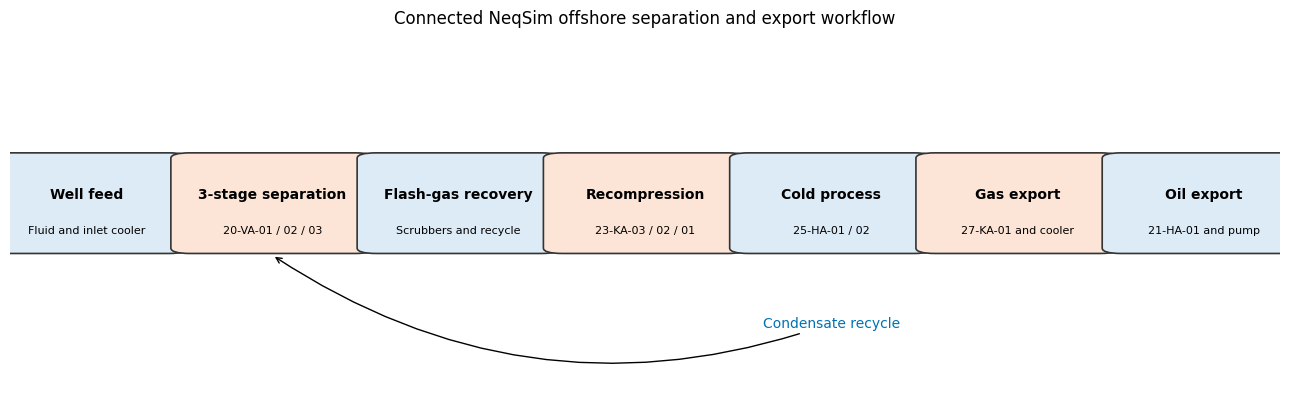

In [16]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

graphviz_export_options = (
    neqsim.process.processmodel.ProcessSystemGraphvizExporter.GraphvizExportOptions
)
table_placement = graphviz_export_options.TablePlacement.BELOW
graphviz_options = (
    graphviz_export_options.builder()
    .includeStreamTemperatures(True)
    .includeStreamPressures(True)
    .includeStreamFlowRates(True)
    .includeStreamPropertyTable(False)
    .tablePlacement(table_placement)
    .build()
)
process1.exportToGraphviz("process_flow_diagram.dot", graphviz_options)
dot_source = Path("process_flow_diagram.dot").read_text()
assert "20-VA-01" in dot_source
assert "27-KA-01" in dot_source

overview_blocks = [
    ("Well feed", "Fluid and inlet cooler"),
    ("3-stage separation", "20-VA-01 / 02 / 03"),
    ("Flash-gas recovery", "Scrubbers and recycle"),
    ("Recompression", "23-KA-03 / 02 / 01"),
    ("Cold process", "25-HA-01 / 02"),
    ("Gas export", "27-KA-01 and cooler"),
    ("Oil export", "21-HA-01 and pump"),
]
positions = np.linspace(0.06, 0.94, len(overview_blocks))
figure, axis = plt.subplots(figsize=(13.0, 4.2))
axis.set_xlim(0.0, 1.0)
axis.set_ylim(0.0, 1.0)
axis.axis("off")

for index, ((title, detail), x_position) in enumerate(zip(overview_blocks, positions)):
    box = FancyBboxPatch(
        (x_position - 0.065, 0.42),
        0.13,
        0.25,
        boxstyle="round,pad=0.015",
        facecolor="#DDEBF7" if index % 2 == 0 else "#FCE4D6",
        edgecolor="#333333",
        linewidth=1.2,
    )
    axis.add_patch(box)
    axis.text(x_position, 0.57, title, ha="center", va="center", weight="bold")
    axis.text(x_position, 0.47, detail, ha="center", va="center", fontsize=8)
    if index < len(overview_blocks) - 1:
        axis.add_patch(
            FancyArrowPatch(
                (x_position + 0.068, 0.545),
                (positions[index + 1] - 0.068, 0.545),
                arrowstyle="-|>",
                mutation_scale=13,
                color="#444444",
            )
        )

axis.annotate(
    "Condensate recycle",
    xy=(positions[1], 0.40),
    xytext=(positions[4], 0.20),
    arrowprops={"arrowstyle": "->", "connectionstyle": "arc3,rad=-0.25"},
    ha="center",
    color="#0072B2",
)
axis.set_title("Connected NeqSim offshore separation and export workflow", pad=12)
figure.tight_layout()
plt.show()


The complete native report remains available in `results.results`, while the next cells present
only decision-relevant tables. This avoids the original multi-megabyte dictionary display and
makes numerical review practical.

### Preserved legacy native Graphviz rendering

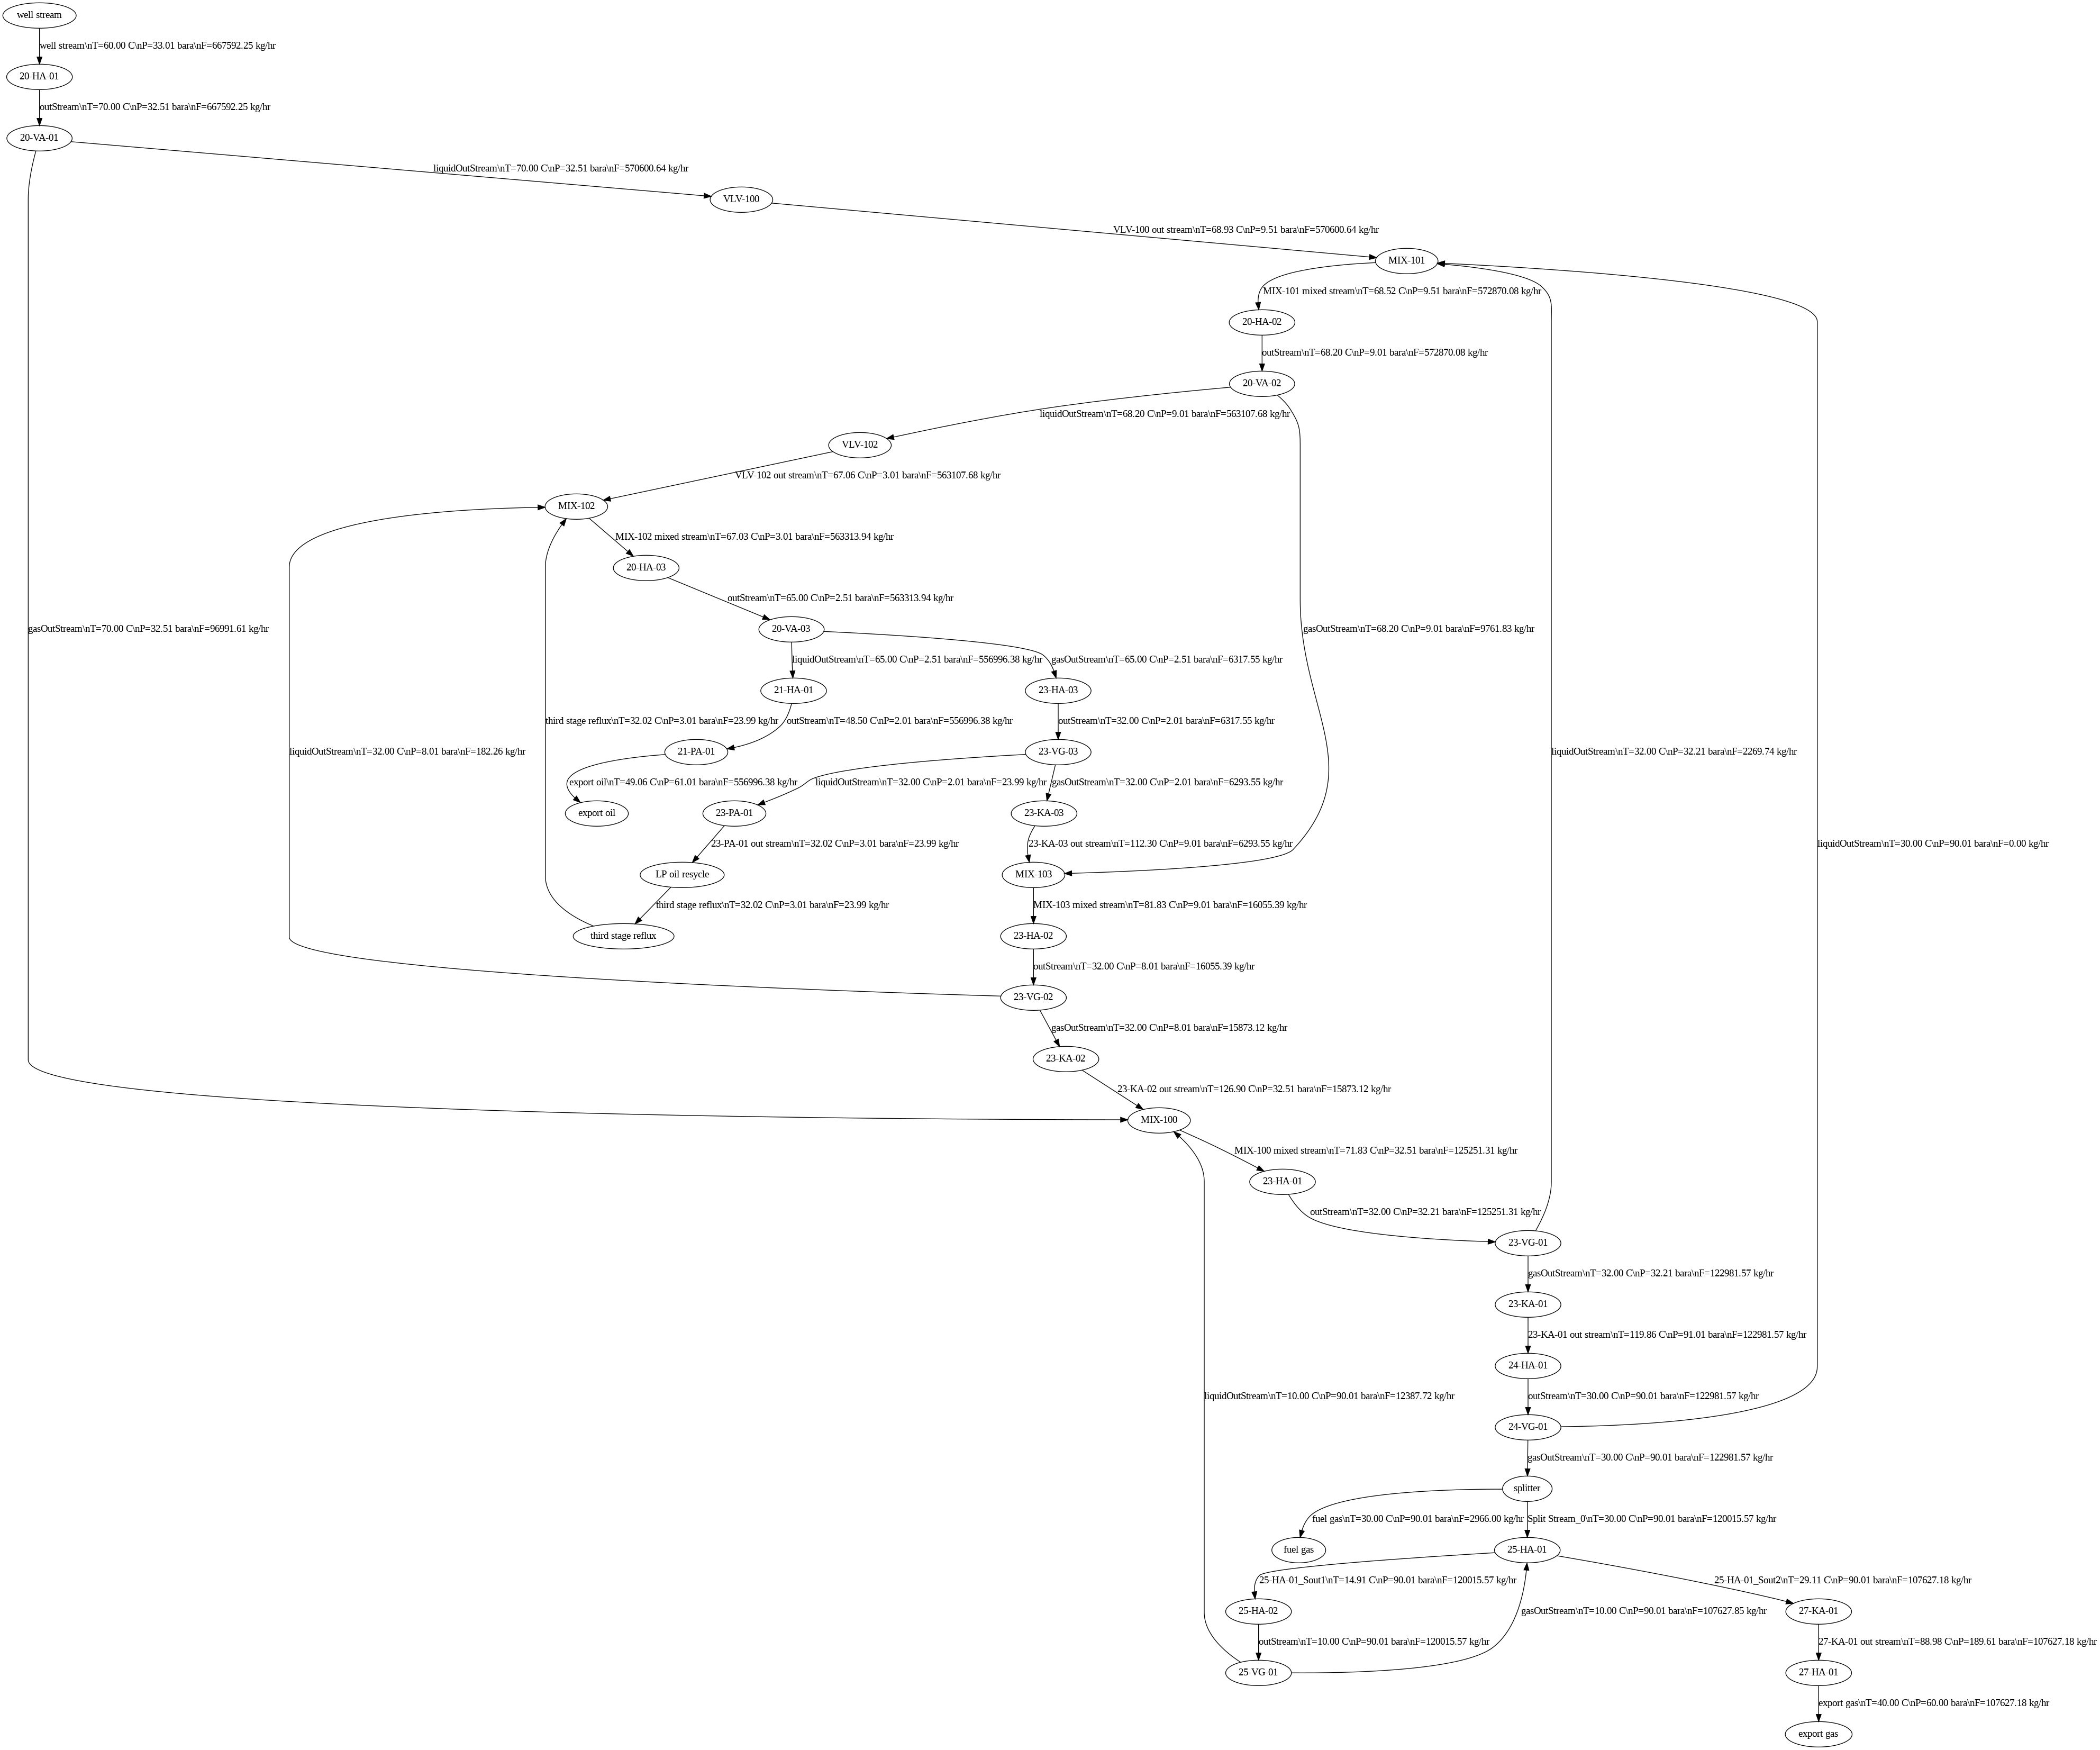

This is the exact stored Graphviz output from source cell 21 in the pre-repair master notebook blob `dc51b7186eaff56d407020339a2891f91bb0123c`. It is retained as a historical visual for provenance and recognizable continuity; its stream-property labels are historical, not current NeqSim results. The current execution above exports a fresh DOT graph and validates key nodes. The compact executed workflow is the readable teaching view because the restricted validation runner has no Graphviz `dot` renderer.


In [17]:
report_inventory = pd.DataFrame(
    {
        "Report section": sorted(results.results),
    }
)
print(f"Native report sections: {len(report_inventory)}")
report_inventory.head(12)


Native report sections: 42


,Report section
0,20-HA-01
1,20-HA-02
2,20-HA-03
3,20-VA-01
4,20-VA-02
5,20-VA-03
6,21-HA-01
7,21-PA-01
8,23-HA-01
9,23-HA-02


In [18]:
from neqsim import open_neqsim, save_neqsim

saved_process_path = Path("process1.neqsim")
save_neqsim(process1, str(saved_process_path))
reopened_process = open_neqsim(str(saved_process_path))

assert reopened_process.getUnit("20-VA-01") is not None
assert reopened_process.getUnit("export gas") is not None
print(f"Round-trip process artifact: {saved_process_path.resolve()}")


Round-trip process artifact: /workspace/scratch/93e2db7bed40/NeqSim-Colab/process1.neqsim


## 4. Product rates, quality, and published benchmark

The paper reports 15,905 m3/day of oil, 12,019 kW of power, and 10.08 psia RVP for its HYSYS base
case. Relative difference is calculated as

$$
\delta_r = 100\frac{y_{NeqSim}-y_{published}}{y_{published}}
$$

where $y$ is the compared response in its displayed unit. The comparison diagnoses model-form
and implementation differences; only conservation and internal consistency are hard pass/fail
checks here.

In [19]:
export_oil_report = results.results["export oil"]
export_gas_report = results.results["export gas"]

oil_export_m3_day = base_metrics["oil_export_m3_day"]
total_power_kw = base_metrics["total_power_kw"]
oil_rvp_psia = float(export_oil_report["properties"]["oil"]["RVP"]["value"]) * 14.5038
oil_tvp_bara = float(export_oil_report["properties"]["oil"]["TVP"]["value"])
gas_gcv_mj_sm3 = float(export_gas_report["properties"]["gas"]["GCV (15/15)"]["value"])
gas_wobbe_mj_sm3 = float(export_gas_report["properties"]["gas"]["WI (15/15)"]["value"])

published_values = {
    "Oil export [m3/day]": 15905.0,
    "Total power [kW]": 12019.0,
    "Oil RVP [psia]": 10.08,
}
neqsim_values = {
    "Oil export [m3/day]": oil_export_m3_day,
    "Total power [kW]": total_power_kw,
    "Oil RVP [psia]": oil_rvp_psia,
}
benchmark_rows = []
for response_name, published_value in published_values.items():
    neqsim_value = neqsim_values[response_name]
    benchmark_rows.append(
        {
            "Response": response_name,
            "Published HYSYS": published_value,
            "NeqSim": neqsim_value,
            "Relative difference [%]": (100.0 * (neqsim_value - published_value) / published_value),
        }
    )

benchmark_table = pd.DataFrame(benchmark_rows)
assert abs(results.mass_balance_percent) < 1.0e-2
assert 0.0 < oil_rvp_psia < 12.0
assert total_power_kw > 0.0
benchmark_table.round(3)


,Response,Published HYSYS,NeqSim,Relative difference [%]
0,Oil export [m3/day],15905.00,19130.542,20.280
1,Total power [kW],12019.00,10431.534,-13.208
2,Oil RVP [psia],10.08,9.579,-4.968


In [20]:
product_quality_table = pd.DataFrame(
    {
        "Indicator": [
            "Overall mass residual",
            "Oil TVP",
            "Oil RVP",
            "Export-gas GCV",
            "Export-gas Wobbe index",
        ],
        "Value": [
            results.mass_balance_percent,
            oil_tvp_bara,
            oil_rvp_psia,
            gas_gcv_mj_sm3,
            gas_wobbe_mj_sm3,
        ],
        "Unit": ["% of feed", "bara", "psia", "MJ/Sm3", "MJ/Sm3"],
    }
)
assert np.isfinite(product_quality_table["Value"]).all()
product_quality_table.round(5)


,Indicator,Value,Unit
0,Overall mass residual,0.00008,% of feed
1,Oil TVP,1.72636,bara
2,Oil RVP,9.57926,psia
3,Export-gas GCV,45.67789,MJ/Sm3
4,Export-gas Wobbe index,53.49065,MJ/Sm3


## 5. Heater and cooler duties

Positive duty adds heat to the process; negative duty removes heat. The process heat exchanger
`25-HA-01` reports its two-sided duty directly, while the single-stream heaters and coolers expose
duty in the native report. The table keeps signs and units explicit.

In [21]:
single_stream_exchangers = [
    "20-HA-01",
    "20-HA-02",
    "20-HA-03",
    "21-HA-01",
    "23-HA-01",
    "23-HA-02",
    "23-HA-03",
    "24-HA-01",
    "25-HA-02",
    "27-HA-01",
]
duty_rows = []
for equipment_name in single_stream_exchangers:
    duty_watt = float(results.results[equipment_name]["data"]["duty"]["value"])
    duty_rows.append(
        {
            "Equipment": equipment_name,
            "Duty [kW]": duty_watt / 1000.0,
            "Service": "Heating" if duty_watt >= 0.0 else "Cooling",
        }
    )

duty_rows.append(
    {
        "Equipment": "25-HA-01",
        "Duty [kW]": float(results.results["25-HA-01"]["duty"]) / 1000.0,
        "Service": "Recovered heat",
    }
)
exchanger_duties = pd.DataFrame(duty_rows)
assert np.isfinite(exchanger_duties["Duty [kW]"]).all()
exchanger_duties.round(2)


,Equipment,Duty [kW],Service
0,20-HA-01,4297.40,Heating
1,20-HA-02,-149.90,Cooling
2,20-HA-03,-587.03,Cooling
3,21-HA-01,-5343.26,Cooling
4,23-HA-01,-2379.63,Cooling
5,23-HA-02,-546.53,Cooling
6,23-HA-03,-105.24,Cooling
7,24-HA-01,-8534.35,Cooling
8,25-HA-02,-649.48,Cooling
9,27-HA-01,-4694.88,Cooling


In [22]:
heat_exchanger_balance = float(results.results["25-HA-01"]["dutyBalance"])
assert np.isclose(heat_exchanger_balance, 1.0, atol=1.0e-8)
pd.DataFrame(
    {
        "Validation": ["25-HA-01 normalized two-sided duty balance"],
        "Value": [heat_exchanger_balance],
        "Acceptance": ["1.0 within 1e-8"],
    }
)


,Validation,Value,Acceptance
0,25-HA-01 normalized two-sided duty balance,1.0,1.0 within 1e-8


## 6. Compressor and pump performance

The reported total power is the sum of four gas compressors and the export-oil pump. Positive,
finite power and physically bounded discharge temperatures are necessary checks. Compressor maps,
driver curves, anti-surge control, and availability are outside this steady-state comparison.

In [23]:
rotating_equipment = ["23-KA-01", "23-KA-02", "23-KA-03", "27-KA-01", "21-PA-01"]
rotating_rows = []
for equipment_name in rotating_equipment:
    unit_report = results.results[equipment_name]
    power_kw = float(unit_report["power"])
    if equipment_name == "21-PA-01":
        power_kw /= 1000.0
    rotating_rows.append(
        {
            "Equipment": equipment_name,
            "Power [kW]": power_kw,
            "Discharge temperature [degC]": float(unit_report["dischargeTemperature"]),
        }
    )

rotating_equipment_table = pd.DataFrame(rotating_rows)
assert np.isclose(
    rotating_equipment_table["Power [kW]"].sum(),
    total_power_kw,
    rtol=1.0e-8,
)
rotating_equipment_table.round(2)


,Equipment,Power [kW],Discharge temperature [degC]
0,23-KA-01,5335.67,119.86
1,23-KA-02,749.86,126.92
2,23-KA-03,310.61,127.30
3,27-KA-01,2947.40,88.98
4,21-PA-01,1087.99,49.06


In [24]:
assert (rotating_equipment_table["Power [kW]"] > 0.0).all()
assert (
    rotating_equipment_table["Discharge temperature [degC]"]
    .between(
        0.0,
        200.0,
    )
    .all()
)

rotating_validation = pd.DataFrame(
    {
        "Check": ["Positive powers", "Discharge temperatures", "Power summation"],
        "Status": ["PASS", "PASS", "PASS"],
    }
)
rotating_validation


,Check,Status
0,Positive powers,PASS
1,Discharge temperatures,PASS
2,Power summation,PASS


## 7. Deterministic 100-case Latin-hypercube study

The original 100-case sensitivity example is preserved and made deterministic. Each row is a
fresh NeqSim process; no recycle state is shared. A seeded Latin-hypercube design covers the
15-dimensional operating box more uniformly than independent random draws. Independent cases are
executed in bounded Java-thread batches and only compact metrics are retained.

Completed 100 fresh cases in 58.2 s


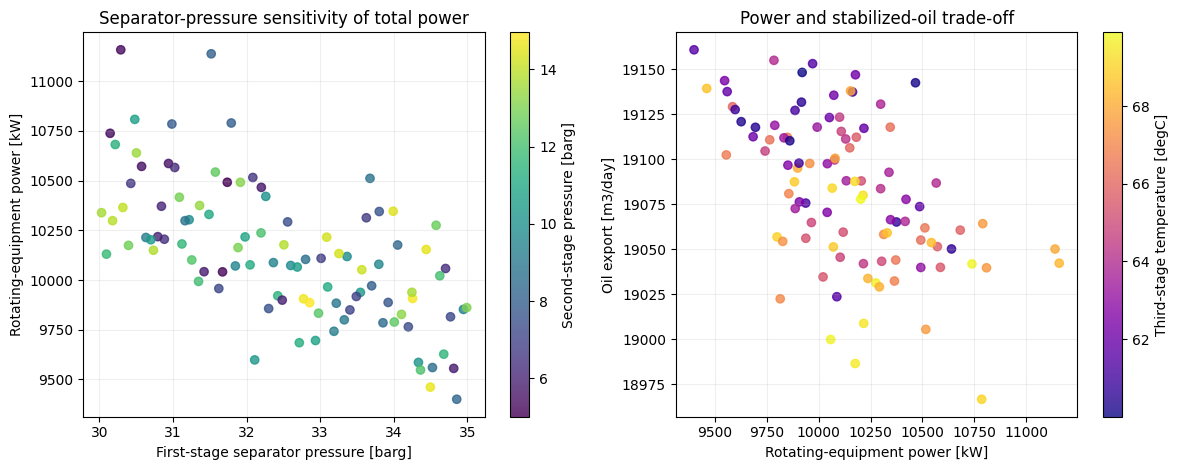

,total_power_kw,oil_export_m3_day,mass_balance_percent
count,100.000000,100.000000,100.000000
mean,10135.770412,19082.731931,0.000061
std,343.638436,41.083399,0.000339
min,9400.472872,18966.694449,-0.000145
25%,9896.129241,19053.127536,-0.000034
50%,10113.848903,19083.760938,0.000046
75%,10340.308418,19115.830717,0.000090
max,11158.086187,19160.710428,0.003330


In [25]:
from scipy.stats import qmc

variable_names = [
    "Tsep1",
    "Tsep2",
    "Tsep3",
    "Tscrub1",
    "Tscrub2",
    "Tscrub3",
    "Tscrub4",
    "Psep1",
    "Psep2",
    "Psep3",
    "Pcomp1",
    "P_gas_export",
    "Trefig",
    "P_oil_export",
    "T_oil_export",
]
bounds = [
    (65.0, 75.0),
    (65.0, 70.0),
    (60.0, 70.0),
    (25.0, 40.0),
    (25.0, 40.0),
    (25.0, 40.0),
    (25.0, 40.0),
    (30.0, 35.0),
    (5.0, 15.0),
    (1.0, 2.0),
    (90.0, 95.0),
    (180.0, 190.0),
    (10.0, 20.0),
    (55.0, 65.0),
    (45.0, 50.0),
]


def build_latin_hypercube_cases(number_of_cases=100, seed=20260809):
    sampler = qmc.LatinHypercube(d=len(variable_names), seed=seed)
    unit_samples = sampler.random(number_of_cases)
    lower_bounds = np.asarray([item[0] for item in bounds])
    upper_bounds = np.asarray([item[1] for item in bounds])
    scaled_samples = qmc.scale(unit_samples, lower_bounds, upper_bounds)

    cases = []
    for sample in scaled_samples:
        parameters = inputparam.copy()
        parameters.update(dict(zip(variable_names, sample)))
        parameters["Tsep2"] = max(parameters["Tsep2"], parameters["Tsep3"])
        parameters["Tsep1"] = max(parameters["Tsep1"], parameters["Tsep2"])
        cases.append(parameters)
    return cases


def run_process_cases(case_parameters, batch_size=8):
    case_rows = []
    for batch_start in range(0, len(case_parameters), batch_size):
        batch = case_parameters[batch_start : batch_start + batch_size]
        active_cases = []
        for parameters in batch:
            process = getprocess()
            validated_input = ProcessInput(**parameters)
            updateinput(process, validated_input)
            calculation_thread = process.runAsThread()
            active_cases.append((parameters, process, calculation_thread))

        for parameters, process, calculation_thread in active_cases:
            calculation_thread.join(180000)
            if calculation_thread.isAlive():
                calculation_thread.interrupt()
                calculation_thread.join()
                raise TimeoutError("A Latin-hypercube process case timed out.")
            metrics = extract_process_metrics(process)
            if abs(metrics["mass_balance_percent"]) >= 1.0e-2:
                converged = process.runUntilConverged(50)
                metrics = extract_process_metrics(process)
                if not converged or abs(metrics["mass_balance_percent"]) >= 1.0e-2:
                    raise RuntimeError(
                        "Latin-hypercube case did not reach the 0.01% mass-closure gate: "
                        f"{metrics['mass_balance_percent']:.8f}%"
                    )
            row = {name: parameters[name] for name in variable_names}
            row.update(metrics)
            case_rows.append(row)
    return pd.DataFrame(case_rows)


parametric_start = time.perf_counter()
sampled_cases = build_latin_hypercube_cases(number_of_cases=100)
scenario_df = run_process_cases(sampled_cases)
parametric_elapsed_seconds = time.perf_counter() - parametric_start

assert len(scenario_df) == 100
assert np.isfinite(scenario_df.select_dtypes(include=[np.number])).all().all()
max_scenario_mass_balance_percent = scenario_df["mass_balance_percent"].abs().max()
assert max_scenario_mass_balance_percent < 1.0e-2, (
    f"Worst Latin-hypercube mass imbalance was {max_scenario_mass_balance_percent:.8f}%"
)

figure, axes = plt.subplots(1, 2, figsize=(12.0, 4.8))
power_scatter = axes[0].scatter(
    scenario_df["Psep1"],
    scenario_df["total_power_kw"],
    c=scenario_df["Psep2"],
    cmap="viridis",
    alpha=0.8,
)
axes[0].set(
    title="Separator-pressure sensitivity of total power",
    xlabel="First-stage separator pressure [barg]",
    ylabel="Rotating-equipment power [kW]",
)
figure.colorbar(power_scatter, ax=axes[0], label="Second-stage pressure [barg]")

oil_scatter = axes[1].scatter(
    scenario_df["total_power_kw"],
    scenario_df["oil_export_m3_day"],
    c=scenario_df["Tsep3"],
    cmap="plasma",
    alpha=0.8,
)
axes[1].set(
    title="Power and stabilized-oil trade-off",
    xlabel="Rotating-equipment power [kW]",
    ylabel="Oil export [m3/day]",
)
figure.colorbar(oil_scatter, ax=axes[1], label="Third-stage temperature [degC]")
for axis in axes:
    axis.grid(alpha=0.2)
figure.tight_layout()
plt.show()

print(f"Completed {len(scenario_df)} fresh cases in " f"{parametric_elapsed_seconds:.1f} s")
scenario_df[["total_power_kw", "oil_export_m3_day", "mass_balance_percent"]].describe()


## 8. Direct black-box process optimization

This preserved optimization example now varies two influential separator pressures against the
rigorous NeqSim process instead of exposing fifteen noisy finite-difference directions at once.
SLSQP enforces $P_{sep,1}-P_{sep,2}\geq1$ bar. Every objective evaluation starts from a fresh
process and applies a large penalty if mass closure is not achieved. The result is a local
engineering screen, not proof of a global optimum.

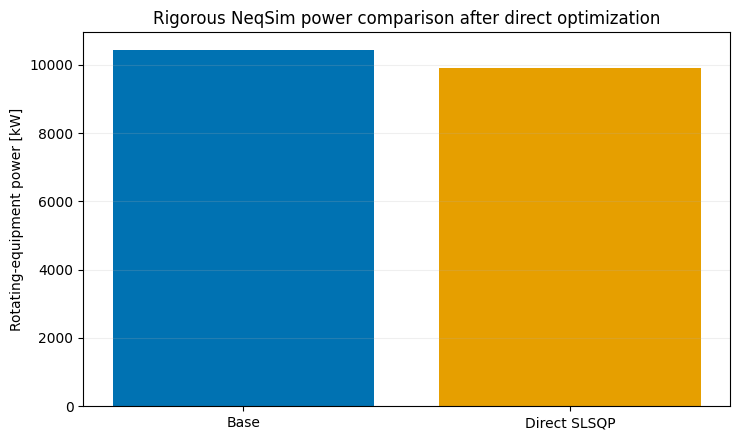

,Case,Psep1 [barg],Psep2 [barg],Power [kW],Oil [m3/day],RVP [psia]
0,Base,31.5,8.000,10431.534,19130.542,9.579
1,Direct SLSQP,35.0,9.157,9909.949,19133.216,9.594


In [26]:
from scipy.optimize import minimize

direct_evaluation_cache = {}


def direct_power_objective(pressure_vector):
    cache_key = tuple(np.round(np.asarray(pressure_vector, dtype=float), 7))
    if cache_key in direct_evaluation_cache:
        return direct_evaluation_cache[cache_key]["total_power_kw"]

    parameters = inputparam.copy()
    parameters["Psep1"] = float(pressure_vector[0])
    parameters["Psep2"] = float(pressure_vector[1])
    process = getprocess()
    updateinput(process, ProcessInput(**parameters))
    process.run()
    metrics = extract_process_metrics(process)
    penalty = 0.0
    if abs(metrics["mass_balance_percent"]) >= 1.0e-2:
        penalty = 1.0e6
    direct_evaluation_cache[cache_key] = metrics
    return metrics["total_power_kw"] + penalty


direct_optimization = minimize(
    direct_power_objective,
    x0=np.array([inputparam["Psep1"], inputparam["Psep2"]]),
    method="SLSQP",
    bounds=[(30.0, 35.0), (5.0, 15.0)],
    constraints=[
        {
            "type": "ineq",
            "fun": lambda values: values[0] - values[1] - 1.0,
        }
    ],
    options={"maxiter": 8, "ftol": 1.0e-3, "disp": False, "eps": 0.05},
)

direct_parameters = inputparam.copy()
direct_parameters["Psep1"] = float(direct_optimization.x[0])
direct_parameters["Psep2"] = float(direct_optimization.x[1])
direct_process = getprocess()
direct_result = run_simulation(direct_process, direct_parameters)
direct_metrics = extract_process_metrics(direct_process)
direct_rvp_psia = (
    float(direct_result.results["export oil"]["properties"]["oil"]["RVP"]["value"]) * 14.5038
)

assert direct_optimization.success
assert direct_parameters["Psep1"] > direct_parameters["Psep2"]
assert abs(direct_result.mass_balance_percent) < 1.0e-2
assert direct_rvp_psia < 12.0

direct_comparison = pd.DataFrame(
    {
        "Case": ["Base", "Direct SLSQP"],
        "Psep1 [barg]": [inputparam["Psep1"], direct_parameters["Psep1"]],
        "Psep2 [barg]": [inputparam["Psep2"], direct_parameters["Psep2"]],
        "Power [kW]": [total_power_kw, direct_metrics["total_power_kw"]],
        "Oil [m3/day]": [oil_export_m3_day, direct_metrics["oil_export_m3_day"]],
        "RVP [psia]": [oil_rvp_psia, direct_rvp_psia],
    }
)

figure, axis = plt.subplots(figsize=(7.5, 4.5))
axis.bar(
    direct_comparison["Case"],
    direct_comparison["Power [kW]"],
    color=["#0072B2", "#E69F00"],
)
axis.set(
    title="Rigorous NeqSim power comparison after direct optimization",
    ylabel="Rotating-equipment power [kW]",
)
axis.grid(axis="y", alpha=0.2)
figure.tight_layout()
plt.show()
direct_comparison.round(3)


## 9. Surrogate modeling and rigorous candidate validation

The 100 already executed Latin-hypercube cases are reused rather than simulating a second,
disconnected random dataset. A random forest predicts total power, and held-out predictions are
compared with rigorous NeqSim values before the surrogate is optimized. Differential evolution is
appropriate for the non-smooth tree ensemble. The selected candidate is then rerun in a fresh
NeqSim process and must pass mass closure and the 12 psia RVP screen.

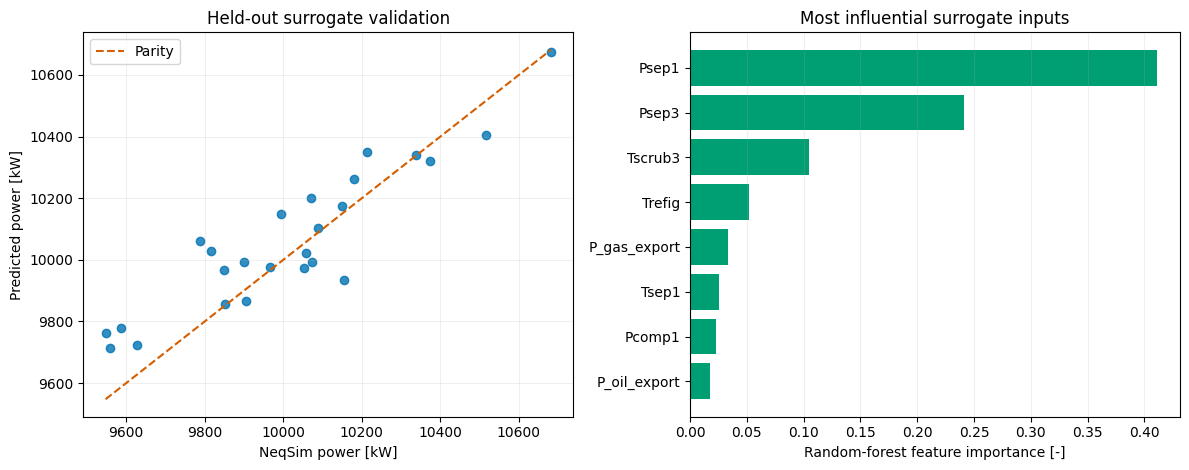

,Metric,Value,Unit
0,Held-out R2,0.797,-
1,Held-out MAE,101.470,kW
2,Candidate predicted power,9603.350,kW
3,Candidate NeqSim power,9365.247,kW
4,Candidate prediction error,2.542,%
5,Candidate RVP,10.392,psia


In [27]:
from scipy.optimize import differential_evolution
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

feature_data = scenario_df[variable_names]
target_power = scenario_df["total_power_kw"]
train_features, test_features, train_target, test_target = train_test_split(
    feature_data,
    target_power,
    test_size=0.25,
    random_state=20260809,
)
surrogate_model = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=2,
    random_state=20260809,
    n_jobs=-1,
)
surrogate_model.fit(train_features, train_target)
test_prediction = surrogate_model.predict(test_features)
surrogate_mae_kw = mean_absolute_error(test_target, test_prediction)
surrogate_r2 = r2_score(test_target, test_prediction)


def surrogate_objective(values):
    values = np.asarray(values, dtype=float)
    candidate = pd.DataFrame([values], columns=variable_names)
    penalty = 0.0
    if candidate.at[0, "Psep1"] <= candidate.at[0, "Psep2"] + 1.0:
        penalty += 1.0e5
    if candidate.at[0, "Psep2"] <= candidate.at[0, "Psep3"] + 1.0:
        penalty += 1.0e5
    if candidate.at[0, "Tsep1"] < candidate.at[0, "Tsep2"]:
        penalty += 1.0e5
    if candidate.at[0, "Tsep2"] < candidate.at[0, "Tsep3"]:
        penalty += 1.0e5
    return float(surrogate_model.predict(candidate)[0]) + penalty


surrogate_optimization = differential_evolution(
    surrogate_objective,
    bounds=bounds,
    seed=20260809,
    maxiter=20,
    popsize=8,
    polish=False,
    workers=1,
)
surrogate_parameters = inputparam.copy()
surrogate_parameters.update(dict(zip(variable_names, surrogate_optimization.x)))

surrogate_process = getprocess()
surrogate_result = run_simulation(surrogate_process, surrogate_parameters)
surrogate_metrics = extract_process_metrics(surrogate_process)
surrogate_rvp_psia = (
    float(surrogate_result.results["export oil"]["properties"]["oil"]["RVP"]["value"]) * 14.5038
)
predicted_candidate_power_kw = surrogate_objective(surrogate_optimization.x)
candidate_error_percent = (
    100.0
    * (predicted_candidate_power_kw - surrogate_metrics["total_power_kw"])
    / surrogate_metrics["total_power_kw"]
)

assert np.isfinite(test_prediction).all()
assert surrogate_r2 > 0.5
assert abs(surrogate_result.mass_balance_percent) < 1.0e-2
assert surrogate_rvp_psia < 12.0

figure, axes = plt.subplots(1, 2, figsize=(12.0, 4.8))
axes[0].scatter(test_target, test_prediction, color="#0072B2", alpha=0.8)
parity_limits = [
    min(test_target.min(), test_prediction.min()),
    max(test_target.max(), test_prediction.max()),
]
axes[0].plot(parity_limits, parity_limits, "--", color="#D55E00", label="Parity")
axes[0].set(
    title="Held-out surrogate validation",
    xlabel="NeqSim power [kW]",
    ylabel="Predicted power [kW]",
)
axes[0].legend()
axes[0].grid(alpha=0.2)

importance_order = np.argsort(surrogate_model.feature_importances_)[-8:]
axes[1].barh(
    np.asarray(variable_names)[importance_order],
    surrogate_model.feature_importances_[importance_order],
    color="#009E73",
)
axes[1].set(
    title="Most influential surrogate inputs",
    xlabel="Random-forest feature importance [-]",
)
axes[1].grid(axis="x", alpha=0.2)
figure.tight_layout()
plt.show()

surrogate_validation = pd.DataFrame(
    {
        "Metric": [
            "Held-out R2",
            "Held-out MAE",
            "Candidate predicted power",
            "Candidate NeqSim power",
            "Candidate prediction error",
            "Candidate RVP",
        ],
        "Value": [
            surrogate_r2,
            surrogate_mae_kw,
            predicted_candidate_power_kw,
            surrogate_metrics["total_power_kw"],
            candidate_error_percent,
            surrogate_rvp_psia,
        ],
        "Unit": ["-", "kW", "kW", "kW", "%", "psia"],
    }
)
surrogate_validation.round(3)


## 10. Parallel independent process calculations

Parallelism reduces elapsed time only when cases are independent and the available CPU and memory
justify concurrency. Each process owns its streams and thermodynamic systems; no mutable object is
shared. The first example preserves direct `runAsThread()` use. The second uses NeqSim's managed
`NeqSimThreadPool`, which centralizes pool size, queueing, shutdown behavior, and returned futures.
Timing from a shared notebook runtime is illustrative rather than a formal benchmark. After timing, every model is qualified sequentially with `runUntilConverged` before concurrent results are checked within 1e-6 kW; this is below one microwatt and covers only floating-point scheduling noise.

In [28]:
available_cpus = os.cpu_count() or 1
parallel_power_tolerance_kw = 1.0e-6
managed_pool = neqsim.util.NeqSimThreadPool
parallel_runtime = pd.DataFrame(
    {
        "Runtime property": [
            "Logical CPUs visible to Python",
            "Managed NeqSim pool size",
            "Default NeqSim pool size",
        ],
        "Value": [
            available_cpus,
            managed_pool.getPoolSize(),
            managed_pool.getDefaultPoolSize(),
        ],
    }
)
parallel_runtime



def qualify_parallel_models(models):
    qualified_metrics = []
    for model in models:
        converged = model.runUntilConverged(50)
        metrics = extract_process_metrics(model)
        if not converged or abs(metrics["mass_balance_percent"]) >= 1.0e-2:
            raise RuntimeError(
                "Parallel case did not reach the 0.01% mass-closure gate: "
                f"{metrics['mass_balance_percent']:.8f}%"
            )
        qualified_metrics.append(metrics)
    return qualified_metrics


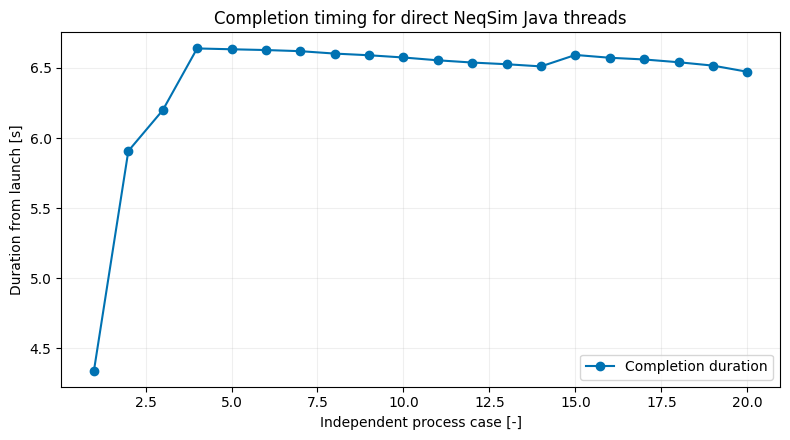

,Cases,Wall time [s],Mean completion duration [s],Power spread [kW]
0,20,6.7967,6.4064,0.0


In [29]:
number_of_process_simulations = 20
process_models = []


def run_many_parallel(number_of_cases=20):
    calculation_threads = []
    start_times = []
    end_times = []
    models = []
    global_start = time.perf_counter()

    for _ in range(number_of_cases):
        process = getprocess()
        updateinput(process, ProcessInput(**inputparam))
        calculation_threads.append(process.runAsThread())
        start_times.append(time.perf_counter())
        models.append(process)

    for calculation_thread in calculation_threads:
        calculation_thread.join(180000)
        if calculation_thread.isAlive():
            calculation_thread.interrupt()
            calculation_thread.join()
            raise TimeoutError("A direct Java-thread case timed out.")
        end_times.append(time.perf_counter())

    wall_time = time.perf_counter() - global_start
    durations = np.asarray(end_times) - np.asarray(start_times)
    return models, durations, wall_time


process_models, direct_thread_durations, direct_thread_wall_seconds = run_many_parallel(
    number_of_process_simulations
)
direct_thread_metrics = qualify_parallel_models(process_models)
direct_power_values = np.asarray([metrics["total_power_kw"] for metrics in direct_thread_metrics])

assert len(process_models) == number_of_process_simulations
assert np.allclose(
    direct_power_values, direct_power_values[0], rtol=0.0, atol=parallel_power_tolerance_kw
)

figure, axis = plt.subplots(figsize=(8.0, 4.5))
axis.plot(
    np.arange(1, number_of_process_simulations + 1),
    direct_thread_durations,
    marker="o",
    color="#0072B2",
    label="Completion duration",
)
axis.set(
    title="Completion timing for direct NeqSim Java threads",
    xlabel="Independent process case [-]",
    ylabel="Duration from launch [s]",
)
axis.grid(alpha=0.2)
axis.legend()
figure.tight_layout()
plt.show()

pd.DataFrame(
    {
        "Cases": [number_of_process_simulations],
        "Wall time [s]": [direct_thread_wall_seconds],
        "Mean completion duration [s]": [direct_thread_durations.mean()],
        "Power spread [kW]": [np.ptp(direct_power_values)],
    }
).round(4)


In [30]:
process_model_number = 3
selected_parallel_process = process_models[process_model_number]
selected_parallel_metrics = extract_process_metrics(selected_parallel_process)
assert np.isclose(
    selected_parallel_metrics["total_power_kw"],
    base_metrics["total_power_kw"],
    atol=parallel_power_tolerance_kw,
)
pd.DataFrame([selected_parallel_metrics]).round(6)


,total_power_kw,oil_export_m3_day,gas_export_msm3_day,mass_balance_percent
0,10431.534102,19130.542443,2.900748,0.000076


### Managed NeqSim thread pool

The managed pool accepts each fresh `ProcessSystem` as a Java `Runnable` and returns a `Future`.
Pool size is capped by the visible CPU count and restored after the example. Futures propagate
exceptions through `get()`, providing a clearer fail-loud contract than polling thread state.

In [31]:
original_pool_size = managed_pool.getPoolSize()
requested_pool_size = max(1, min(available_cpus, 8))
managed_pool.setPoolSize(requested_pool_size)

managed_pool_configuration = pd.DataFrame(
    {
        "Setting": ["Original size", "Example size", "Maximum queue capacity"],
        "Value": [
            original_pool_size,
            managed_pool.getPoolSize(),
            managed_pool.getMaxQueueCapacity(),
        ],
    }
)
managed_pool_configuration


,Setting,Value
0,Original size,8
1,Example size,8
2,Maximum queue capacity,0


In [32]:
process1 = getprocess()
updateinput(process1, ProcessInput(**inputparam))
assert process1.getUnit("export gas") is not None
print("A fresh process is ready for the managed-pool demonstration.")


A fresh process is ready for the managed-pool demonstration.


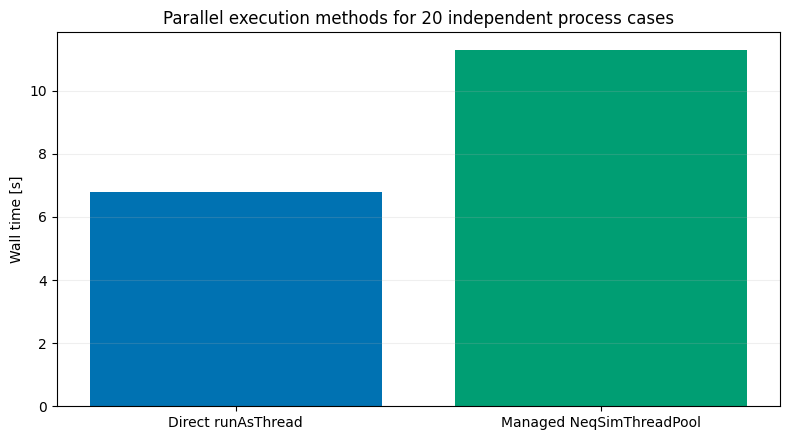

,Execution method,Cases,Wall time [s],Power spread [kW]
0,Direct runAsThread,20,6.7967,0.0
1,Managed NeqSimThreadPool,20,11.2845,0.0


In [33]:
managed_models = []
managed_futures = []
managed_start = time.perf_counter()

for _ in range(number_of_process_simulations):
    process = getprocess()
    updateinput(process, ProcessInput(**inputparam))
    managed_models.append(process)
    managed_futures.append(managed_pool.submit(process))

for future in managed_futures:
    future.get()

managed_wall_seconds = time.perf_counter() - managed_start
managed_metrics = qualify_parallel_models(managed_models)
managed_power_values = np.asarray(
    [metrics["total_power_kw"] for metrics in managed_metrics]
)
managed_pool.setPoolSize(original_pool_size)

assert all(future.isDone() for future in managed_futures)
assert np.allclose(managed_power_values, managed_power_values[0], atol=parallel_power_tolerance_kw)
assert np.isclose(managed_power_values[0], total_power_kw, atol=parallel_power_tolerance_kw)

parallel_comparison = pd.DataFrame(
    {
        "Execution method": ["Direct runAsThread", "Managed NeqSimThreadPool"],
        "Cases": [number_of_process_simulations, number_of_process_simulations],
        "Wall time [s]": [direct_thread_wall_seconds, managed_wall_seconds],
        "Power spread [kW]": [
            np.ptp(direct_power_values),
            np.ptp(managed_power_values),
        ],
    }
)

figure, axis = plt.subplots(figsize=(8.0, 4.5))
axis.bar(
    parallel_comparison["Execution method"],
    parallel_comparison["Wall time [s]"],
    color=["#0072B2", "#009E73"],
)
axis.set(
    title="Parallel execution methods for 20 independent process cases",
    ylabel="Wall time [s]",
)
axis.grid(axis="y", alpha=0.2)
figure.tight_layout()
plt.show()
parallel_comparison.round(4)


## 11. Integrated application conclusion

The complete workflow now connects a governed fluid assay to a 39-unit NeqSim process,
compares the base case with published HYSYS responses, evaluates 100 fresh operating
cases, validates both direct and surrogate candidates, and demonstrates two supported
parallel-execution APIs. Reuse begins with `getprocess()` and `inputparam`: copy the base
dictionary, change only governed fields, run a fresh model, and accept a result only after
convergence, mass closure, product-quality, equipment-limit, and model-domain checks.

In [34]:
final_case_summary = pd.DataFrame(
    {
        "Case": ["Base", "Direct SLSQP", "Surrogate candidate"],
        "Power [kW]": [
            total_power_kw,
            direct_metrics["total_power_kw"],
            surrogate_metrics["total_power_kw"],
        ],
        "Oil [m3/day]": [
            oil_export_m3_day,
            direct_metrics["oil_export_m3_day"],
            surrogate_metrics["oil_export_m3_day"],
        ],
        "RVP [psia]": [oil_rvp_psia, direct_rvp_psia, surrogate_rvp_psia],
        "Mass residual [%]": [
            results.mass_balance_percent,
            direct_result.mass_balance_percent,
            surrogate_result.mass_balance_percent,
        ],
    }
)

assert (final_case_summary["Power [kW]"] > 0.0).all()
assert (final_case_summary["Oil [m3/day]"] > 0.0).all()
assert (final_case_summary["RVP [psia]"] < 12.0).all()
assert final_case_summary["Mass residual [%]"].abs().max() < 1.0e-2
assert managed_pool.getPoolSize() == original_pool_size
final_case_summary.round(4)


,Case,Power [kW],Oil [m3/day],RVP [psia],Mass residual [%]
0,Base,10431.5341,19130.5424,9.5793,0.0001
1,Direct SLSQP,9909.9486,19133.2158,9.5943,0.0000
2,Surrogate candidate,9365.2472,19133.4754,10.3923,-0.0001


## Limitations, applicability, and next steps

- The HYSYS comparison is not a strict cross-simulator regression because COSTALD liquid
  density, detailed utility consumers, fuel-gas adjustment, and the profit model are not
  reproduced exactly.
- The PR fluid is an illustrative published assay. Reconcile pseudo-components, binary
  interactions, density, viscosity, and product tests to laboratory data before design use.
- The steady-state model excludes compressor maps, anti-surge control, dynamic inventories,
  relief/blowdown, reliability, emissions, and equipment mechanical limits.
- The random-forest candidate is accepted only inside this sampled domain and only after a
  fresh rigorous NeqSim run. Extrapolation is not justified.
- Parallel timing depends on runtime CPU, memory, JVM warm-up, and queue settings; repeat a
  benchmark on the intended deployment platform.

Practical exercises: add the paper's utility and profit model; include the 12 psia RVP
constraint in every sampled row; compare PR liquid-density corrections; add compressor-map
feasibility; and replace the random forest with a uncertainty-aware Gaussian-process
surrogate.

References: Andreasen (2020), https://doi.org/10.3390/chemengineering4010011; NeqSim
documentation, https://equinor.github.io/neqsim/; and the current NeqSim source repository,
https://github.com/equinor/neqsim.